# Black Scholes functions and IV

# Phase 1

In [1]:
import numpy as np
import scipy.stats  
import pandas as pd
import plotly.graph_objects as go
import matplotlib.gridspec as gridspec
from matplotlib import cm

def d1_func(S, K, T, r, sigma):
    return (np.log(S/K) + (r + (sigma**2)/2)*T) / (sigma * np.sqrt(T))

def d2_func(d1, T, sigma):
    return d1 - (sigma * np.sqrt(T))


def bs_call_price(S, K, T, r, sigma):
    d1 = d1_func(S, K, T, r, sigma)
    d2 = d2_func(d1, T, sigma)

    return S * scipy.stats.norm.cdf(d1) - K * np.exp(-r*T) * scipy.stats.norm.cdf(d2)

def bs_put_price(S, K, T, r, sigma):
    d1 = d1_func(S, K, T, r, sigma)
    d2 = d2_func(d1, T, sigma)

    return K * np.exp(-r*T) * scipy.stats.norm.cdf(-d2) - S * scipy.stats.norm.cdf(-d1)

## Verify Call-Put parity  
$C - P = S - Ke^{-rT}$

In [2]:
S=100
K=100 
r=0.05 
T=1.0
sigma=0.2

d1 = d1_func(S, K, T, r, sigma)

d2 = d2_func(d1, T, sigma)

call_price = bs_call_price(S, K, r, T, sigma)
put_price = bs_put_price(S, K, r, T, sigma)


lhs = call_price - put_price

rhs = S - K * np.exp(-r * T)


difference = abs(lhs - rhs)

difference

np.float64(5.329070518200751e-15)

## Black-Scholes Greeks

Delta: Sensitivity to underlying price.   
$\Delta_C = \frac{\partial C}{\partial S} = \Phi(d_1)$  
$\Delta_P = \frac{\partial P}{\partial S} = \Phi(d_1) - 1 = -\Phi(-d_1)$  

Gamma: Rate of change of delta (same for calls and puts).   
$\Gamma = \frac{\partial^2 C}{\partial S^2} = \frac{\partial^2 P}{\partial S^2} = \frac{\phi(d_1)}{S\sigma \sqrt{T}}$

where $\phi(x) = \frac{1}{\sqrt{2\pi}}e^{-\frac{x^2}{2}}$

Vega: Sensitivity to volatility (same for calls and puts). 

$\nu = \frac{\partial C}{\partial \sigma} = S\phi (d_1) \sqrt{T}$



In [3]:
def delta_call(d1):
    return scipy.stats.norm.cdf(d1)

def delta_put(d1):
    return scipy.stats.norm.cdf(d1) - 1

def gamma(d1, S, sigma, T):
    return scipy.stats.norm.pdf(d1) / (S * sigma * np.sqrt(T))

def vega(S, K, T, r, sigma):
    d1 = d1_func(S, K, T, r, sigma)
    return S * scipy.stats.norm.pdf(d1) * np.sqrt(T)



### Verify the greeks. 
$\Delta_{call} ​- \Delta_{put}​ = 1$  
$\nu = S^2\sigma \sqrt{T} \cdot \Gamma$

In [4]:
# Should equal 1
print(d1)
delta_call(d1) - delta_put(d1)

0.35000000000000003


np.float64(1.0)

In [5]:
# Should be approximately equal

vega_val = vega(S, K, T, r, sigma)
gamma_val = gamma(d1, S, sigma, T)

vega_val, gamma_val*S**2*sigma*T

(np.float64(37.52403469169379), np.float64(37.52403469169379))

## Implied volatility
Goal: find the volatility value such that the observed market conditions are reconstructed.  

$f(\sigma) = BS_{price} - Market_{price} = 0$

Use Newton Raphson:  
$\sigma_{n+1} = \sigma_n - \frac{f(\sigma)}{f'(\sigma)}$

In [6]:
def implied_volatility(option_price, S, K, T, r, sigma_init=None, option_type='call'):
    tol = 1e-8
    if option_type.lower() == 'call':
        price_func = bs_call_price
    elif option_type.lower() == 'put':
        price_func = bs_put_price
    else:
        raise ValueError(f"Invalid option_type: {option_type}. Must be 'call' or 'put'")
    
    if sigma_init is None:
        sigma_init = 0.25
    
    num_iters = 15
    sigma = sigma_init
    for i in range(num_iters):
        BS_price = price_func(S, K, T, r, sigma)
        diff = BS_price - option_price
        
        # Check convergence FIRST
        if abs(diff) < tol:
            return sigma
            
        # If not converged, take Newton step
        vega_val = vega(S, K, T, r, sigma)

        if vega_val < 1e-10:  # Vega too small
            raise ValueError(f"Vega collapsed to {vega_val} - likely deep ITM/OTM or near expiry")

        sigma -= diff / vega_val
        # Enforce bounds
        sigma = max(0.001, min(sigma, 5.0)) 
    # After loop ends without returning
    raise ValueError(f"IV did not converge after {num_iters} iterations. Last diff: {diff}")


In [7]:
# Generate a proper test
S = 100.0
K = 100.0
T = 0.25
r = 0.05
true_sigma = 0.20

# Generate the "market price" from known volatility
market_price = bs_call_price(S, K, T, r, true_sigma)
print(f"Market price at σ={true_sigma}: {market_price}")

# Now invert it
iv = implied_volatility(
    option_price=market_price,
    S=S, K=K, T=T, r=r,
    option_type='call'
)

print(f"\nImplied Vol: {iv:.8f}")
print(f"True Vol:    {true_sigma:.8f}")
print(f"Error:       {abs(iv - true_sigma):.2e}")

Market price at σ=0.2: 4.614997129602855

Implied Vol: 0.20000000
True Vol:    0.20000000
Error:       6.42e-11


In [8]:
test_cases = [
    (100, 100, 0.25, 0.05, 0.15),  # ATM, low vol
    (100, 100, 0.25, 0.05, 0.30),  # ATM, high vol
    (100, 110, 0.25, 0.05, 0.20),  # OTM call
    (100, 90, 0.25, 0.05, 0.20),   # ITM call
]

for S, K, T, r, true_vol in test_cases:
    market_price = bs_call_price(S, K, T, r, true_vol)
    recovered_vol = implied_volatility(market_price, S, K, T, r, option_type='call')
    error = abs(recovered_vol - true_vol)
    print(f"K={K}, σ_true={true_vol:.2f}, σ_recovered={recovered_vol:.6f}, error={error:.2e}")

K=100, σ_true=0.15, σ_recovered=0.150000, error=1.11e-16
K=100, σ_true=0.30, σ_recovered=0.300000, error=9.54e-13
K=110, σ_true=0.20, σ_recovered=0.200000, error=2.22e-10
K=90, σ_true=0.20, σ_recovered=0.200000, error=3.39e-15


In [9]:
def implied_volatility_trace(option_price, S, K, T, r, sigma_init=None, option_type='call'):
    """
    Same as implied_volatility but returns iteration history for plotting.
    
    Returns:
        sigma: Final converged volatility
        history: dict with keys 'sigma', 'price', 'diff', 'vega' - lists of values at each iteration
    """
    tol = 1e-8
    if option_type.lower() == 'call':
        price_func = bs_call_price
    elif option_type.lower() == 'put':
        price_func = bs_put_price
    else:
        raise ValueError(f"Invalid option_type: {option_type}. Must be 'call' or 'put'")
    
    if sigma_init is None:
        sigma_init = 0.25
    
    num_iters = 10
    sigma = sigma_init
    
    # History tracking
    history = {
        'sigma': [],
        'price': [],
        'diff': [],
        'vega': []
    }
    
    for i in range(num_iters):
        BS_price = price_func(S, K, T, r, sigma)
        diff = BS_price - option_price
        vega_val = vega(S, K, T, r, sigma)
        
        # Record state BEFORE update
        history['sigma'].append(sigma)
        history['price'].append(BS_price)
        history['diff'].append(diff)
        history['vega'].append(vega_val)
        
        # Check convergence
        if abs(diff) < tol:
            return sigma, history
        
        # Vega safety check
        if vega_val < 1e-10:
            raise ValueError(f"Vega collapsed to {vega_val} - likely deep ITM/OTM or near expiry")
        
        # Take Newton step
        sigma -= diff / vega_val
        
        # Enforce bounds
        sigma = max(0.001, min(sigma, 5.0))
    
    # After loop ends without returning
    raise ValueError(f"IV did not converge after {num_iters} iterations. Last diff: {diff}")

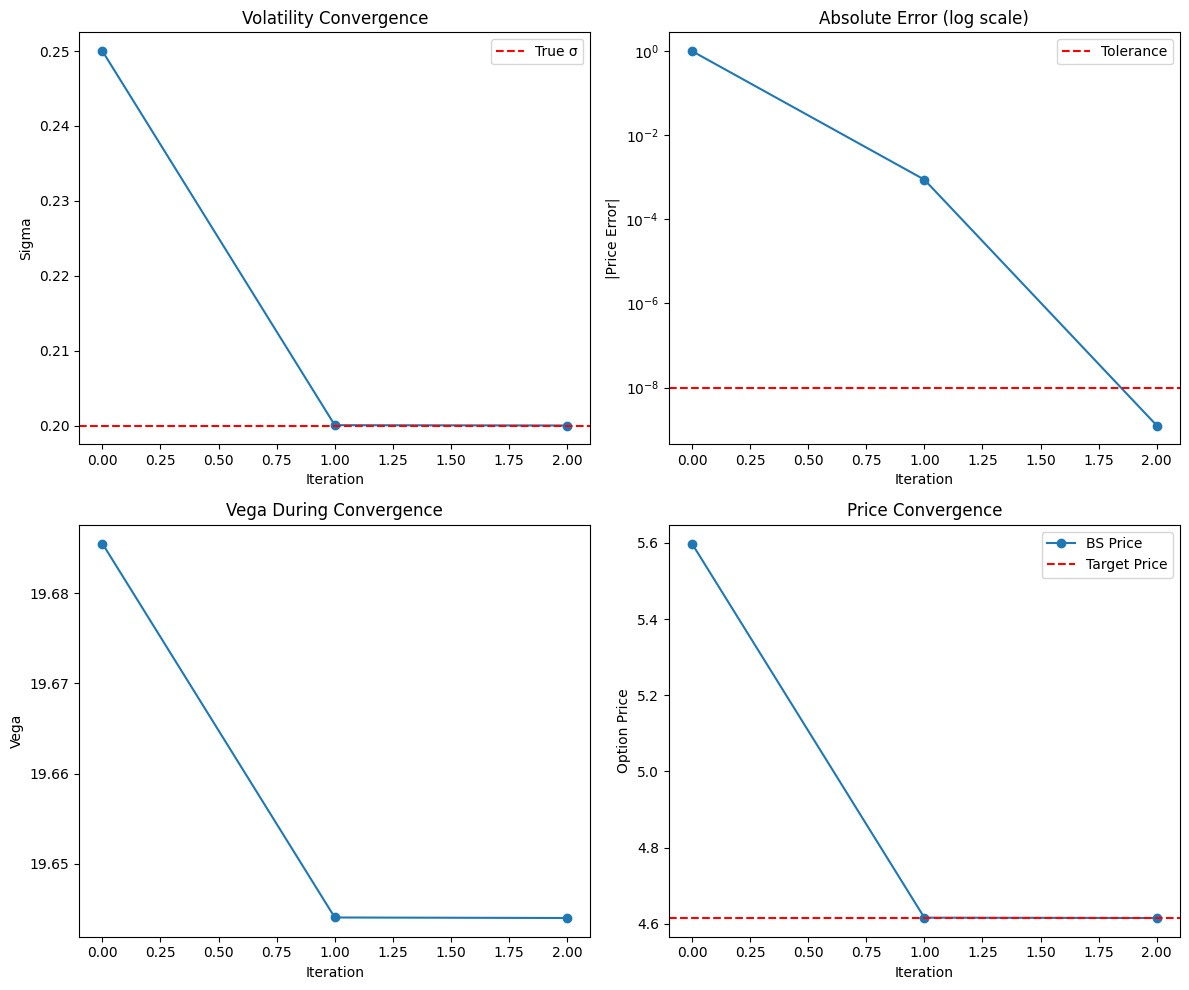

Converged in 3 iterations
Final sigma: 0.20000000


In [10]:
# Run with trace
market_price = bs_call_price(100, 100, 0.25, 0.05, 0.20)
final_sigma, hist = implied_volatility_trace(
    market_price, 100, 100, 0.25, 0.05, option_type='call'
)

# Plot convergence
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Sigma convergence
axes[0, 0].plot(hist['sigma'], marker='o')
axes[0, 0].axhline(0.20, color='r', linestyle='--', label='True σ')
axes[0, 0].set_ylabel('Sigma')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].legend()
axes[0, 0].set_title('Volatility Convergence')

# Price error
axes[0, 1].plot(np.abs(hist['diff']), marker='o')
axes[0, 1].set_yscale('log')
axes[0, 1].axhline(1e-8, color='r', linestyle='--', label='Tolerance')
axes[0, 1].set_ylabel('|Price Error|')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].legend()
axes[0, 1].set_title('Absolute Error (log scale)')

# Vega values
axes[1, 0].plot(hist['vega'], marker='o')
axes[1, 0].set_ylabel('Vega')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_title('Vega During Convergence')

# BS Price vs Target
axes[1, 1].plot(hist['price'], marker='o', label='BS Price')
axes[1, 1].axhline(market_price, color='r', linestyle='--', label='Target Price')
axes[1, 1].set_ylabel('Option Price')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].legend()
axes[1, 1].set_title('Price Convergence')

plt.tight_layout()
plt.show()

print(f"Converged in {len(hist['sigma'])} iterations")
print(f"Final sigma: {final_sigma:.8f}")

# Phase 2

## Define options grid

In [11]:
# Market conditions
S = 100  # spot price
r = 0.05  # risk-free rate
q = 0.0  # dividend yield (start with 0 for simplicity)

# Strikes as percentages of spot
strike_moneyness = [
    0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 
    0.97, 0.98, 0.99, 1.00, 1.01, 1.02, 1.03, 1.05,
    1.10, 1.15, 1.20, 1.25, 1.30
]
strikes = [S * m for m in strike_moneyness]

# Maturities in years
maturities = [1/12, 2/12, 3/12, 6/12, 9/12, 1.0]  # 1M, 2M, 3M, 6M, 9M, 1Y

# Option types
option_types = ['call', 'put']

sigma_flat = 0.20  # 20% vol everywhere

## Construct df of options prices using implied vol

S, S/K, T, r, type, sigma_flat -> bs price, delta, vega

In [12]:
opt_prices_df = pd.DataFrame(columns=['maturity', 'strike', 'moneyness', 'option_type', 'true_iv', 'bs_price', 'intrinsic_value'])

for T in maturities:
    for K in strikes:
        for opt_type in option_types:
            true_iv = sigma_flat  # (later this becomes σ(K,T))
            
            if opt_type == 'call':
                price = bs_call_price(S, K, T, r, true_iv)
                intrinsic = max(S - K, 0)
            else:
                price = bs_put_price(S, K, T, r, true_iv)
                intrinsic = max(K - S, 0)
            
            row = {
                'maturity': T,
                'strike': K,
                'moneyness': K/S,
                'option_type': opt_type,
                'true_iv': true_iv,
                'bs_price': price,
                'intrinsic_value': intrinsic
            }
            # Append to DataFrame
            opt_prices_df = pd.concat([opt_prices_df, pd.DataFrame([row])], ignore_index=True)

/var/folders/q2/m5_vfjhs3m5b5szm6q3l9dlr0000gn/T/ipykernel_74372/4016681918.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  opt_prices_df = pd.concat([opt_prices_df, pd.DataFrame([row])], ignore_index=True)


In [13]:
opt_prices_df

,maturity,strike,moneyness,option_type,true_iv,bs_price,intrinsic_value
0,0.083333,70.0,0.70,call,0.2,3.029106e+01,30.0
1,0.083333,70.0,0.70,put,0.2,1.510373e-10,0.0
2,0.083333,75.0,0.75,call,0.2,2.531185e+01,25.0
3,0.083333,75.0,0.75,put,0.2,1.982993e-07,0.0
4,0.083333,80.0,0.80,call,0.2,2.033269e+01,20.0
...,...,...,...,...,...,...,...
223,1.000000,120.0,1.20,put,0.2,1.739501e+01,20.0
224,1.000000,125.0,1.25,call,0.2,2.324274e+00,0.0
225,1.000000,125.0,1.25,put,0.2,2.122795e+01,25.0
226,1.000000,130.0,1.30,call,0.2,1.639593e+00,0.0


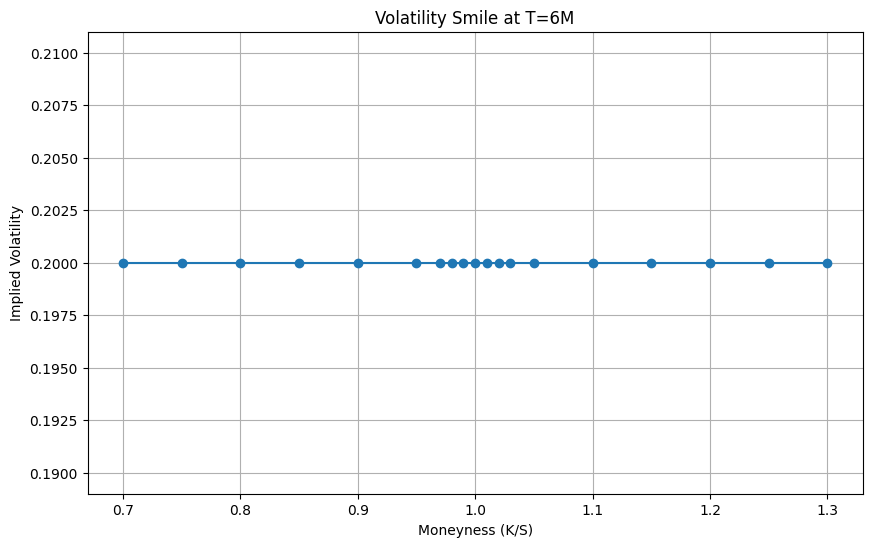

In [14]:
# Filter to just 6-month options, calls only
df_6m = opt_prices_df[(opt_prices_df['maturity'] == 0.5) & 
                       (opt_prices_df['option_type'] == 'call')]

# Plot IV vs moneyness
plt.figure(figsize=(10, 6))
plt.plot(df_6m['moneyness'], df_6m['true_iv'], 'o-')
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Implied Volatility')
plt.title('Volatility Smile at T=6M')
plt.grid(True)
plt.show()

In [15]:
# Just use calls for cleaner visualization
df_calls = opt_prices_df[opt_prices_df['option_type'] == 'call']

fig = go.Figure(data=[go.Mesh3d(
    x=df_calls['moneyness'],
    y=df_calls['maturity'],
    z=df_calls['true_iv'],
    intensity=df_calls['true_iv'],
    colorscale='Viridis',
    showscale=True,
    colorbar=dict(title='IV'),
)])

fig.update_layout(
    title='IV Surface (Flat)',
    scene=dict(
        xaxis_title='Moneyness (K/S)',
        yaxis_title='Maturity (years)',
        zaxis_title='Implied Volatility'
    ),
    width=800, height=700
)
fig.show()

In [16]:
sigma_atm = 0.20
skew_slope = -0.15

rows = []

for T in maturities:
    for K in strikes:
        for opt_type in option_types:
            # NEW: Linear skew formula
            true_iv = sigma_atm + skew_slope * (K/S - 1)
            
            if opt_type == 'call':
                price = bs_call_price(S, K, T, r, true_iv)
                intrinsic = max(S - K, 0)
            else:
                price = bs_put_price(S, K, T, r, true_iv)
                intrinsic = max(K - S, 0)
            
            rows.append({
                'maturity': T,
                'strike': K,
                'moneyness': K/S,
                'option_type': opt_type,
                'true_iv': true_iv,
                'bs_price': price,
                'intrinsic_value': intrinsic
            })

opt_prices_df_skew_lin = pd.DataFrame(rows)

In [17]:
# Just use calls for cleaner visualization
df_calls = opt_prices_df_skew_lin[opt_prices_df_skew_lin['option_type'] == 'call']

fig = go.Figure(data=[go.Mesh3d(
    x=df_calls['moneyness'],
    y=df_calls['maturity'],
    z=df_calls['true_iv'],
    intensity=df_calls['true_iv'],
    colorscale='Viridis',
    showscale=True,
    colorbar=dict(title='IV'),
)])

fig.update_layout(
    title='IV Surface (Linear Skew)',
    scene=dict(
        xaxis_title='Moneyness (K/S)',
        yaxis_title='Maturity (years)',
        zaxis_title='Implied Volatility'
    ),
    width=800, height=700
)
fig.show()

In [18]:
sigma_atm = 0.20
skew_slope = -0.15
curvature = 0.05


rows = []

for T in maturities:
    for K in strikes:
        for opt_type in option_types:
            true_iv = sigma_atm + skew_slope * (K/S - 1) + curvature * (K/S - 1)**2
            
            if opt_type == 'call':
                price = bs_call_price(S, K, T, r, true_iv)
                intrinsic = max(S - K, 0)
            else:
                price = bs_put_price(S, K, T, r, true_iv)
                intrinsic = max(K - S, 0)
            
            rows.append({
                'maturity': T,
                'strike': K,
                'moneyness': K/S,
                'option_type': opt_type,
                'true_iv': true_iv,
                'bs_price': price,
                'intrinsic_value': intrinsic
            })

opt_prices_df_skew_smile = pd.DataFrame(rows)

In [19]:
# Just use calls for cleaner visualization
df_calls = opt_prices_df_skew_smile[opt_prices_df_skew_smile['option_type'] == 'call']

fig = go.Figure(data=[go.Mesh3d(
    x=df_calls['moneyness'],
    y=df_calls['maturity'],
    z=df_calls['true_iv'],
    intensity=df_calls['true_iv'],
    colorscale='Viridis',
    showscale=True,
    colorbar=dict(title='IV'),
)])

fig.update_layout(
    title='IV Surface (Skew and Smile)',
    scene=dict(
        xaxis_title='Moneyness (K/S)',
        yaxis_title='Maturity (years)',
        zaxis_title='Implied Volatility'
    ),
    width=800, height=700
)
fig.show()

In [20]:
skew_slope = -0.15
curvature = 0.05

rows = []

for T in maturities:
    sigma_atm = 0.15 + 0.05 * np.sqrt(T)
    for K in strikes:
        for opt_type in option_types:
            true_iv = sigma_atm + skew_slope * (K/S - 1) + curvature * (K/S - 1)**2
            
            if opt_type == 'call':
                price = bs_call_price(S, K, T, r, true_iv)
                intrinsic = max(S - K, 0)
            else:
                price = bs_put_price(S, K, T, r, true_iv)
                intrinsic = max(K - S, 0)
            
            rows.append({
                'maturity': T,
                'strike': K,
                'moneyness': K/S,
                'option_type': opt_type,
                'true_iv': true_iv,
                'bs_price': price,
                'intrinsic_value': intrinsic
            })

opt_prices_df_skew_smile_structure = pd.DataFrame(rows)

In [21]:
# Just use calls for cleaner visualization
df_calls = opt_prices_df_skew_smile_structure[opt_prices_df_skew_smile_structure['option_type'] == 'call']

fig = go.Figure(data=[go.Mesh3d(
    x=df_calls['moneyness'],
    y=df_calls['maturity'],
    z=df_calls['true_iv'],
    intensity=df_calls['true_iv'],
    colorscale='Viridis',
    showscale=True,
    colorbar=dict(title='IV'),
    opacity=0.7
)])

fig.update_layout(
    title='IV Surface (Skew, Smile and Time Structure)',
    scene=dict(
        xaxis_title='Moneyness (K/S)',
        yaxis_title='Maturity (years)',
        zaxis_title='Implied Volatility'
    ),
    width=800, height=700
)
fig.show()

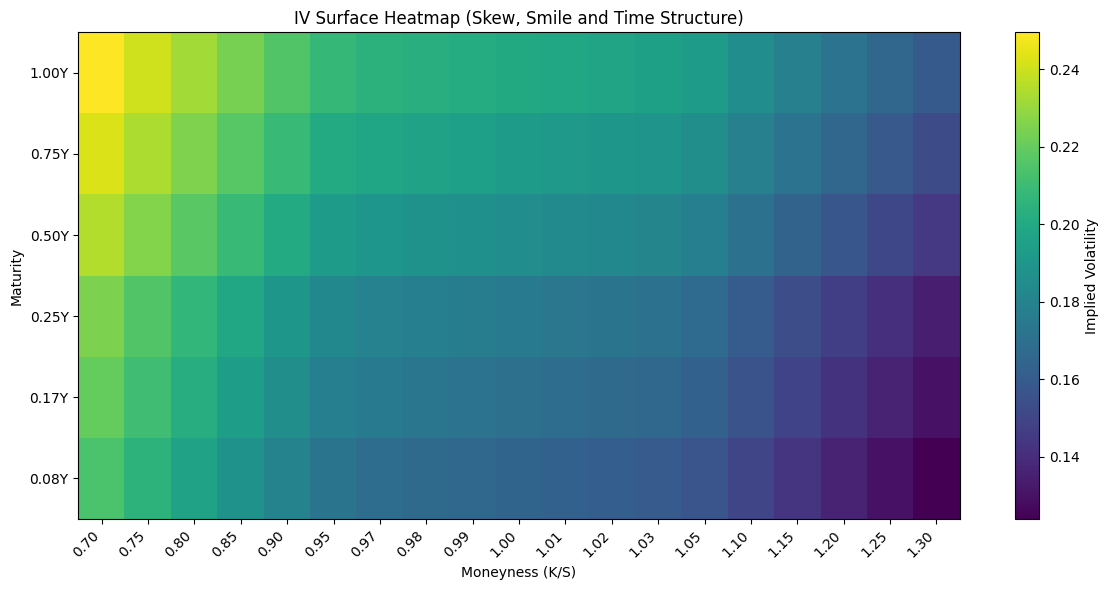

In [22]:
# Heatmap visualization of IV surface
df_calls = opt_prices_df_skew_smile_structure[opt_prices_df_skew_smile_structure['option_type'] == 'call']

# Pivot to get moneyness vs maturity grid
heatmap_data = df_calls.pivot(index='maturity', columns='moneyness', values='true_iv')

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='viridis', origin='lower')

# Set tick labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels([f'{m:.2f}' for m in heatmap_data.columns], rotation=45, ha='right')
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels([f'{t:.2f}Y' for t in heatmap_data.index])

ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Maturity')
ax.set_title('IV Surface Heatmap (Skew, Smile and Time Structure)')

cbar = fig.colorbar(im, ax=ax, label='Implied Volatility')
plt.tight_layout()
plt.show()

In [23]:
opt_prices_df_skew_smile_structure.to_csv('synthetic_market_data.csv', index=False)

In [24]:
def sigma_true_full(K, T, S=100, skew_slope=-0.15, curvature=0.05):
    """Skew + smile + term structure"""
    import numpy as np
    
    # ATM vol depends on maturity
    sigma_atm = 0.15 + 0.05 * np.sqrt(T)
    
    moneyness = K/S
    offset = moneyness - 1
    return sigma_atm + skew_slope * offset + curvature * offset**2

In [25]:
def generate_option_chain(S, r, strikes, maturities, option_types, sigma_func):
    """
    Generate option chain with prices from a given IV surface function.
    
    Parameters:
    -----------
    sigma_func : callable
        Function signature: sigma_func(K, T, S) -> implied_volatility
    """
    rows = []
    
    for T in maturities:
        for K in strikes:
            for opt_type in option_types:
                # Use the provided IV surface function
                true_iv = sigma_func(K, T, S)
                
                if opt_type == 'call':
                    price = bs_call_price(S, K, T, r, true_iv)
                    intrinsic = max(S - K, 0)
                else:
                    price = bs_put_price(S, K, T, r, true_iv)
                    intrinsic = max(K - S, 0)
                
                rows.append({
                    'maturity': T,
                    'strike': K,
                    'moneyness': K/S,
                    'option_type': opt_type,
                    'true_iv': true_iv,
                    'bs_price': price,
                    'intrinsic_value': intrinsic
                })
    
    return pd.DataFrame(rows)

# Phase 3
## Heston Characteristic Function

The Heston model allows volatility to be stochastic. While we can't write down the PDF of log(S_T) in closed form, we *can* write down its **characteristic function**:

$$
\phi(\omega) = \mathbb{E}[e^{i\omega \log(S_T)}] = \exp(C(\tau,\omega) + D(\tau,\omega)v_0 + i\omega\log(S_0))
$$

The functions C(τ,ω) and D(τ,ω) solve ODEs derived from the Heston dynamics and have analytical solutions. They encode how model parameters affect the distribution of terminal log-prices:
- **D(τ,ω)**: How current variance v₀ propagates to log(S_T)
- **C(τ,ω)**: Cumulative effect of long-run variance θ and drift r

### Analytical Forms for C and D

For numeraire j ∈ {1,2}, the characteristic function components are:

$$
D_j(\tau,\omega) = \frac{b_j - \rho\xi i\omega - d_j}{\xi^2} \cdot \frac{1 - e^{-d_j\tau}}{1 - g_j e^{-d_j\tau}}
$$

$$
C_j(\tau,\omega) = r\tau i\omega + \frac{\kappa\theta}{\xi^2}\left[(b_j - \rho\xi i\omega - d_j)\tau - 2\ln\left(\frac{1 - g_j e^{-d_j\tau}}{1 - g_j}\right)\right]
$$

where the auxiliary terms are:

$$
d_j = \sqrt{(\rho\xi i\omega - b_j)^2 - \xi^2(2u_j i\omega - \omega^2)}
$$

$$
g_j = \frac{b_j - \rho\xi i\omega - d_j}{b_j - \rho\xi i\omega + d_j}
$$

The parameters $u_j$ and $b_j$ differ between numeraires:
- **j=1** (stock numeraire): $u_1 = \frac{1}{2}$, $b_1 = \kappa - \rho\xi$
- **j=2** (money market numeraire): $u_2 = -\frac{1}{2}$, $b_2 = \kappa$

These adjustments reflect the **change of measure** (Radon-Nikodym derivative) when switching between probability measures for computing the two probabilities. The $u_j$ term modifies how the volatility process contributes to each probability.

**From characteristic function to prices:**

The characteristic function φ(ω) completely characterizes the distribution of log(S_T). We use **Fourier inversion** to extract probabilities without ever computing the PDF:

$$
P_j(S_T>K) = \frac{1}{2} + \frac{1}{\pi}\int_0^\infty \text{Re}\left[\frac{e^{-i\omega\log(K)} \phi_j(\omega)}{i\omega}\right] d\omega
$$

where φ₁(ω) and φ₂(ω) are modified characteristic functions (using adjusted C and D for different numeraires). These probabilities combine to give the option price:

$$
\text{Call} = S \cdot P_1 - Ke^{-rT} \cdot P_2
$$

This mirrors Black-Scholes $(S·N(d_1) - K·e^{-rT}·N(d_2))$, but P₁ and P₂ are computed via numerical integration rather than normal CDF lookup.


In [26]:
from scipy.integrate import quad

def heston_b(kappa, rho, xi, j_mode):
    if j_mode == 1:
        return kappa - rho * xi
    elif j_mode == 2:
        return kappa
    else:
        raise ValueError(f'j_mode value must be 1 or 2, not {j_mode}')


def heston_u(j_mode):
    """Return u parameter for numeraire j"""
    if j_mode == 1:
        return 0.5
    elif j_mode == 2:
        return -0.5
    else:
        raise ValueError(f'j_mode value must be 1 or 2, not {j_mode}')


def heston_d(omega, kappa, xi, rho, j_mode):
    """Compute discriminant d_j with proper branch selection"""
    b_j = heston_b(kappa, rho, xi, j_mode)
    u_j = heston_u(j_mode)
    
    # d_j = √[(ρξiω - b_j)² - ξ²(2u_j·iω - ω²)]
    # Rearranging: √[(ρξiω - b_j)² + ξ²(ω² - 2u_j·iω)]
    d = np.sqrt((rho * xi * 1j * omega - b_j)**2 + 
                xi**2 * (omega**2 - 2 * u_j * 1j * omega))
    
    # Lord-Kahl: ensure Re(d) > 0
    if np.real(d) < 0:
        d = -d
    
    return d


def heston_g(omega, kappa, xi, rho, j_mode):
    """Compute auxiliary parameter g_j"""
    b_j = heston_b(kappa, rho, xi, j_mode)
    d_j = heston_d(omega, kappa, xi, rho, j_mode)
    return (b_j - rho * xi * 1j * omega - d_j) / (b_j - rho * xi * 1j * omega + d_j)


def heston_D(tau, omega, kappa, xi, rho, j_mode):
    """Compute D function using d_j and g_j"""
    b_j = heston_b(kappa, rho, xi, j_mode)
    d_j = heston_d(omega, kappa, xi, rho, j_mode)
    g_j = heston_g(omega, kappa, xi, rho, j_mode)

    return ((b_j - rho * xi * 1j * omega - d_j) / (xi ** 2)) * \
           (1 - np.exp(-d_j * tau)) / (1 - g_j * np.exp(-d_j * tau))


def heston_C(tau, omega, kappa, theta, xi, rho, r, j_mode):
    """Compute C function using d_j, g_j and parameters"""
    b_j = heston_b(kappa, rho, xi, j_mode)
    d_j = heston_d(omega, kappa, xi, rho, j_mode)
    g_j = heston_g(omega, kappa, xi, rho, j_mode)

    return r * tau * 1j * omega + \
           (kappa * theta / (xi ** 2)) * \
           ((b_j - rho * xi * 1j * omega - d_j) * tau - 
            2 * np.log((1 - g_j * np.exp(-d_j * tau)) / (1 - g_j)))


def heston_integrand(omega, K, S, tau, r, v0, kappa, theta, xi, rho, j_mode):
    """Build integrand Re[...]"""
    C_j = heston_C(tau, omega, kappa, theta, xi, rho, r, j_mode)
    D_j = heston_D(tau, omega, kappa, xi, rho, j_mode)
    phi_j = np.exp(C_j + D_j * v0 + (1j * omega * np.log(S)))

    return np.real((np.exp(-1j * omega * np.log(K)) * phi_j) / (1j * omega))


def heston_probability(K, S, T, r, v0, kappa, theta, xi, rho, j_mode, omega_max=100):
    """Numerically integrate integrand from 0 to ω_max"""
    result, error = quad(
        heston_integrand, 
        1e-10, 
        omega_max, 
        args=(K, S, T, r, v0, kappa, theta, xi, rho, j_mode)
    )
    if error > 1e-6:
        print(f"(Warning) Integration error: {error}")
    return 0.5 + result / np.pi


def heston_call_price(S, K, T, r, v0, kappa, theta, xi, rho):
    """Compute P1 and P2, return S·P1 - K·e^(-rT)·P2"""
    P_1 = heston_probability(K, S, T, r, v0, kappa, theta, xi, rho, 1)
    P_2 = heston_probability(K, S, T, r, v0, kappa, theta, xi, rho, 2)

    return S * P_1 - K * np.exp(-r * T) * P_2


def heston_put_price(S, K, T, r, v0, kappa, theta, xi, rho):
    """Put via put-call parity: P = C - S + K*e^(-rT)"""
    call = heston_call_price(S, K, T, r, v0, kappa, theta, xi, rho)
    return call - S + K * np.exp(-r * T)

In [27]:
# Test with reasonable parameters
S = 100.0
K = 100.0
T = 0.25
r = 0.05
v0 = 0.04      # 20% initial vol
kappa = 2.0
theta = 0.04   # 20% long-run vol
xi = 0.3
rho = -0.7

price = heston_call_price(S, K, T, r, v0, kappa, theta, xi, rho)
print(f"Heston call price: ${price:.4f}")

# Sanity checks:
# 1. Price should be positive
assert price > 0, "Price must be positive"

# 2. Price should be less than stock price (call can't be worth more than stock)
assert price < S, "Call price must be less than stock price"

# 3. For ATM option, should be roughly S*N(0.5) - K*exp(-rT)*N(0.5) ballpark
# With 20% vol, 3-month ATM call should be around $4-6
assert 2 < price < 10, f"ATM call price {price:.2f} seems unreasonable"

print("✓ Basic sanity checks passed")

Heston call price: $4.5871
✓ Basic sanity checks passed


In [28]:
# BS limit: xi → 0
S = 100.0
K = 100.0
T = 0.25
r = 0.05
sigma = 0.20

# BS price
from scipy.stats import norm
def bs_call_price(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

bs_price = bs_call_price(S, K, T, r, sigma)

# Heston with xi ≈ 0
v0 = sigma**2
theta = sigma**2
kappa = 2.0
xi = 1e-4
rho = 0.0

heston_price = heston_call_price(S, K, T, r, v0, kappa, theta, xi, rho)

print(f"BS:     ${bs_price:.6f}")
print(f"Heston: ${heston_price:.6f}")
print(f"Error:  {abs(heston_price - bs_price):.8f}")

BS:     $4.614997
Heston: $4.614997
Error:  0.00000001


In [29]:
# Deep ITM call (S >> K) should be worth approximately S - K*e^(-rT)
S_itm = 150
call_itm = heston_call_price(S_itm, K, T, r, v0, kappa, theta, xi, rho)
intrinsic = S_itm - K * np.exp(-r * T)
assert call_itm > intrinsic * 0.99, f"Deep ITM call {call_itm:.2f} should be near intrinsic {intrinsic:.2f}"
print(f"✓ Deep ITM: ${call_itm:.2f} > ${intrinsic:.2f} (intrinsic)")

# Deep OTM call (S << K) should be nearly worthless
S_otm = 50
call_otm = heston_call_price(S_otm, K, T, r, v0, kappa, theta, xi, rho)
assert call_otm < 0.50, f"Deep OTM call {call_otm:.2f} should be near zero"
print(f"✓ Deep OTM: ${call_otm:.4f} ≈ $0")

✓ Deep ITM: $51.24 > $51.24 (intrinsic)
✓ Deep OTM: $-0.0000 ≈ $0


In [30]:
# Vol-of-Vol (ξ) Effect
# Higher ξ → more smile curvature (OTM IVs rise relative to ATM)

S, T, r = 100.0, 0.25, 0.05
v0, kappa, theta, rho = 0.04, 2.0, 0.04, 0.0

K_otm, K_atm = 110, 100
xi_low, xi_high = 0.1, 0.4  # keep xi_high under Feller violation

def get_iv(K, xi):
    price = heston_call_price(S, K, T, r, v0, kappa, theta, xi, rho)
    return implied_volatility(price, S, K, T, r, option_type='call')

# Smile curvature = IV_otm - IV_atm
curvature_low = get_iv(K_otm, xi_low) - get_iv(K_atm, xi_low)
curvature_high = get_iv(K_otm, xi_high) - get_iv(K_atm, xi_high)

print(f"ξ={xi_low}: IV(K={K_otm}) - IV(K={K_atm}) = {curvature_low:.2%}")
print(f"ξ={xi_high}: IV(K={K_otm}) - IV(K={K_atm}) = {curvature_high:.2%}")

assert curvature_high > curvature_low, f"Higher ξ should increase smile curvature"
print("✓ Higher vol-of-vol increases smile curvature")

ξ=0.1: IV(K=110) - IV(K=100) = 0.02%
ξ=0.4: IV(K=110) - IV(K=100) = 0.41%
✓ Higher vol-of-vol increases smile curvature


In [31]:
# Correlation (ρ) Effect - Creates Volatility Skew
# ρ < 0: OTM puts have higher IV than OTM calls (negative skew)

S, T, r = 100.0, 0.25, 0.05
v0, kappa, theta, xi = 0.04, 2.0, 0.04, 0.3
rho = -0.7

K_put, K_call = 90, 110  # OTM put strike, OTM call strike

price_put_side = heston_call_price(S, K_put, T, r, v0, kappa, theta, xi, rho)
price_call_side = heston_call_price(S, K_call, T, r, v0, kappa, theta, xi, rho)

iv_put_side = implied_volatility(price_put_side, S, K_put, T, r, option_type='call')
iv_call_side = implied_volatility(price_call_side, S, K_call, T, r, option_type='call')

print(f"IV at K={K_put} (OTM put): {iv_put_side:.1%}")
print(f"IV at K={K_call} (OTM call): {iv_call_side:.1%}")

assert iv_put_side > iv_call_side, f"Negative ρ should create negative skew: IV({K_put})={iv_put_side:.1%} <= IV({K_call})={iv_call_side:.1%}"
print(f"✓ Negative ρ creates negative skew (IV difference: {iv_put_side - iv_call_side:.1%})")

IV at K=90 (OTM put): 22.1%
IV at K=110 (OTM call): 17.7%
✓ Negative ρ creates negative skew (IV difference: 4.5%)


In [32]:
def check_feller(kappa, theta, xi):
    """Feller condition: 2κθ > ξ² ensures variance stays positive"""
    feller = 2 * kappa * theta
    threshold = xi ** 2
    
    if feller <= threshold:
        print(f"⚠️  Feller condition VIOLATED: 2κθ={feller:.4f} ≤ ξ²={threshold:.4f}")
        print("    Variance can reach zero - may cause numerical issues")
    else:
        print(f"✓ Feller condition satisfied: 2κθ={feller:.4f} > ξ²={threshold:.4f}")
    
    return feller > threshold

# Test with your parameters
check_feller(kappa, theta, xi=0.1)

✓ Feller condition satisfied: 2κθ=0.1600 > ξ²=0.0100


True

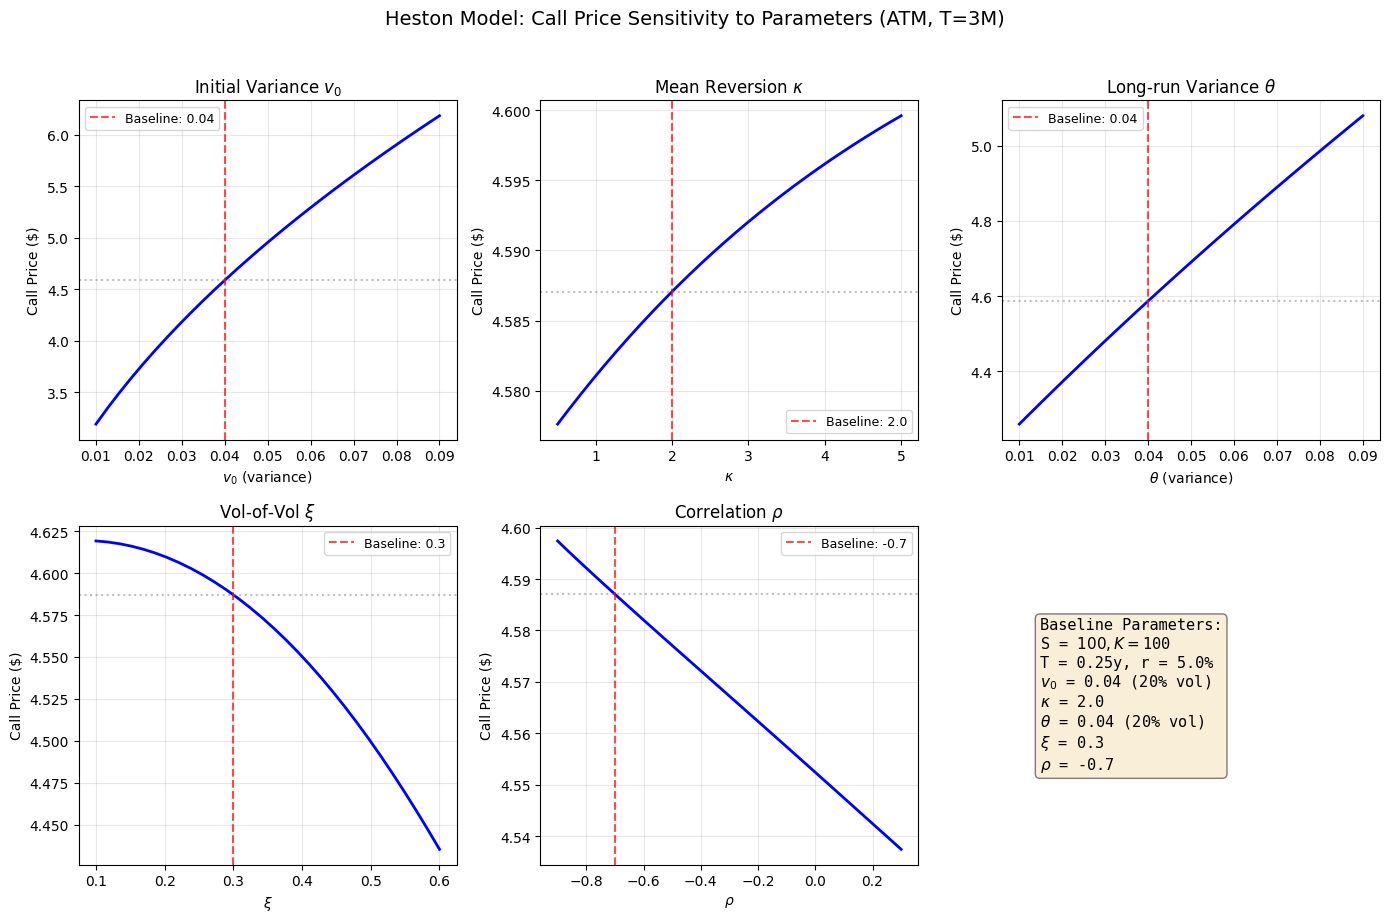


Price Range Summary:
--------------------------------------------------
v0    : $3.19 to $6.19 (range: $3.00)
kappa : $4.58 to $4.60 (range: $0.02)
theta : $4.26 to $5.08 (range: $0.82)
xi    : $4.44 to $4.62 (range: $0.18)
rho   : $4.54 to $4.60 (range: $0.06)


In [33]:
# Heston Price Sensitivity Analysis
# Baseline parameters (realistic equity option values)

baseline = {
    'S': 100.0,
    'K': 100.0,      # ATM
    'T': 0.25,       # 3 months
    'r': 0.05,
    'v0': 0.04,      # 20% initial vol
    'kappa': 2.0,    # moderate mean reversion
    'theta': 0.04,   # 20% long-run vol
    'xi': 0.3,       # moderate vol-of-vol
    'rho': -0.7      # typical equity negative correlation
}

# Parameter ranges to explore
param_ranges = {
    'v0': np.linspace(0.01, 0.09, 30),      # 10% to 30% vol
    'kappa': np.linspace(0.5, 5.0, 30),     # slow to fast mean reversion
    'theta': np.linspace(0.01, 0.09, 30),   # 10% to 30% long-run vol
    'xi': np.linspace(0.1, 0.6, 30),        # low to high vol-of-vol
    'rho': np.linspace(-0.9, 0.3, 30)       # negative to slightly positive correlation
}

# Compute prices for each parameter sweep
sensitivity_results = {}

for param_name, param_values in param_ranges.items():
    prices = []
    for val in param_values:
        # Copy baseline and override one parameter
        params = baseline.copy()
        params[param_name] = val
        
        price = heston_call_price(
            params['S'], params['K'], params['T'], params['r'],
            params['v0'], params['kappa'], params['theta'], params['xi'], params['rho']
        )
        prices.append(price)
    
    sensitivity_results[param_name] = (param_values, np.array(prices))

# Plot all sensitivities
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

param_labels = {
    'v0': ('Initial Variance $v_0$', '$v_0$ (variance)'),
    'kappa': ('Mean Reversion $\\kappa$', '$\\kappa$'),
    'theta': ('Long-run Variance $\\theta$', '$\\theta$ (variance)'),
    'xi': ('Vol-of-Vol $\\xi$', '$\\xi$'),
    'rho': ('Correlation $\\rho$', '$\\rho$')
}

for idx, (param_name, (x_vals, prices)) in enumerate(sensitivity_results.items()):
    ax = axes[idx]
    ax.plot(x_vals, prices, 'b-', linewidth=2)
    
    # Mark baseline value
    baseline_val = baseline[param_name]
    baseline_price = heston_call_price(
        baseline['S'], baseline['K'], baseline['T'], baseline['r'],
        baseline['v0'], baseline['kappa'], baseline['theta'], baseline['xi'], baseline['rho']
    )
    ax.axvline(baseline_val, color='r', linestyle='--', alpha=0.7, label=f'Baseline: {baseline_val}')
    ax.axhline(baseline_price, color='gray', linestyle=':', alpha=0.5)
    
    title, xlabel = param_labels[param_name]
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Call Price ($)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

# Hide the 6th subplot (we only have 5 parameters)
axes[5].axis('off')

# Add baseline info as text in the empty subplot
baseline_text = "Baseline Parameters:\n"
baseline_text += f"S = ${baseline['S']:.0f}, K = ${baseline['K']:.0f}\n"
baseline_text += f"T = {baseline['T']:.2f}y, r = {baseline['r']:.1%}\n"
baseline_text += f"$v_0$ = {baseline['v0']:.2f} ({np.sqrt(baseline['v0']):.0%} vol)\n"
baseline_text += f"$\\kappa$ = {baseline['kappa']:.1f}\n"
baseline_text += f"$\\theta$ = {baseline['theta']:.2f} ({np.sqrt(baseline['theta']):.0%} vol)\n"
baseline_text += f"$\\xi$ = {baseline['xi']:.1f}\n"
baseline_text += f"$\\rho$ = {baseline['rho']:.1f}"
axes[5].text(0.1, 0.5, baseline_text, fontsize=11, verticalalignment='center',
             transform=axes[5].transAxes, family='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Heston Model: Call Price Sensitivity to Parameters (ATM, T=3M)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print price range for each parameter
print("\nPrice Range Summary:")
print("-" * 50)
for param_name, (x_vals, prices) in sensitivity_results.items():
    print(f"{param_name:6s}: ${prices.min():.2f} to ${prices.max():.2f} (range: ${prices.max()-prices.min():.2f})")

# Phase 4

In [34]:
# Market conditions
S = 100  # spot price
r = 0.05  # risk-free rate
q = 0.0  # dividend yield (start with 0 for simplicity)
v0 = 0.04      # 20% initial vol
kappa = 2.0    # moderate mean reversion
theta = 0.04   # 20% long-run vol
xi = 0.3       # moderate vol-of-vol
rho = -0.7      # typical equity negative correlation

# Strikes as percentages of spot
strike_moneyness = [
    0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 
    0.97, 0.98, 0.99, 1.00, 1.01, 1.02, 1.03, 1.05,
    1.10, 1.15, 1.20, 1.25, 1.30
]
strikes = [S * m for m in strike_moneyness]

# Maturities in years
maturities = [1/12, 2/12, 3/12, 6/12, 9/12, 1.0]  # 1M, 2M, 3M, 6M, 9M, 1Y


heston_opt_prices_df = pd.DataFrame(columns=['maturity', 'strike', 'moneyness', 'option_type', 'heston_price', 'intrinsic_value'])

rows = []
for T in maturities:
    for K in strikes:
        for opt_type in option_types:
            if opt_type == 'call':
                price = heston_call_price(S, K, T, r, v0, kappa, theta, xi, rho)
                intrinsic = max(S - K, 0)
            else:
                price = heston_put_price(S, K, T, r, v0, kappa, theta, xi, rho)
                intrinsic = max(K - S, 0)
            
            rows.append({
                'maturity': T,
                'strike': K,
                'moneyness': K/S,
                'option_type': opt_type,
                'heston_price': price,
                'intrinsic_value': intrinsic
            })

heston_opt_prices_df = pd.DataFrame(rows)

In [35]:
heston_opt_prices_df

,maturity,strike,moneyness,option_type,heston_price,intrinsic_value
0,0.083333,70.0,0.70,call,30.291065,30.0
1,0.083333,70.0,0.70,put,0.000006,0.0
2,0.083333,75.0,0.75,call,25.311946,25.0
3,0.083333,75.0,0.75,put,0.000096,0.0
4,0.083333,80.0,0.80,call,20.334014,20.0
...,...,...,...,...,...,...
223,1.000000,120.0,1.20,put,16.480164,20.0
224,1.000000,125.0,1.25,call,1.405724,0.0
225,1.000000,125.0,1.25,put,20.309402,25.0
226,1.000000,130.0,1.30,call,0.799608,0.0


In [36]:
def safe_implied_volatility(price, S, K, T, r, option_type):
    """Wrapper that returns NaN if IV calculation fails"""
    try:
        return implied_volatility(price, S, K, T, r, option_type=option_type)
    except ValueError:
        return np.nan

heston_opt_prices_df['implied_vol'] = heston_opt_prices_df.apply(
    lambda row: safe_implied_volatility(
        row['heston_price'], S, row['strike'], row['maturity'], r, 
        option_type=row['option_type']
    ), 
    axis=1
)

heston_opt_prices_df

,maturity,strike,moneyness,option_type,heston_price,intrinsic_value,implied_vol
0,0.083333,70.0,0.70,call,30.291065,30.0,0.280063
1,0.083333,70.0,0.70,put,0.000006,0.0,0.280063
2,0.083333,75.0,0.75,call,25.311946,25.0,0.263614
3,0.083333,75.0,0.75,put,0.000096,0.0,0.263614
4,0.083333,80.0,0.80,call,20.334014,20.0,0.249127
...,...,...,...,...,...,...,...
223,1.000000,120.0,1.20,put,16.480164,20.0,0.172211
224,1.000000,125.0,1.25,call,1.405724,0.0,0.166804
225,1.000000,125.0,1.25,put,20.309402,25.0,0.166804
226,1.000000,130.0,1.30,call,0.799608,0.0,0.162003


In [37]:
# Filter to calls only and drop NaN IVs
df_heston_calls = heston_opt_prices_df[
    (heston_opt_prices_df['option_type'] == 'call') & 
    (heston_opt_prices_df['implied_vol'].notna())
]

fig = go.Figure(data=[go.Mesh3d(
    x=df_heston_calls['moneyness'],
    y=df_heston_calls['maturity'],
    z=df_heston_calls['implied_vol'],
    intensity=df_heston_calls['implied_vol'],
    colorscale='Viridis',
    showscale=True,
    colorbar=dict(title='IV'),
    opacity=0.7
)])

fig.update_layout(
    title='Heston Implied Volatility Surface',
    scene=dict(
        xaxis_title='Moneyness (K/S)',
        yaxis_title='Maturity (years)',
        zaxis_title='Implied Volatility'
    ),
    width=800, 
    height=700
) 
fig.show()

In [38]:
import ipywidgets as widgets
from IPython.display import display

# Fixed market parameters
S = 100
r = 0.05
strike_moneyness = [
    0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 
    0.97, 0.98, 0.99, 1.00, 1.01, 1.02, 1.03, 1.05,
    1.10, 1.15, 1.20, 1.25, 1.30
]
strikes = [S * m for m in strike_moneyness]
maturities = [1/12, 2/12, 3/12, 6/12, 9/12, 1.0]

def compute_heston_iv_surface(v0, kappa, theta, xi, rho):
    """Compute implied volatility surface for given Heston parameters"""
    rows = []
    for T in maturities:
        for K in strikes:
            try:
                price = heston_call_price(S, K, T, r, v0, kappa, theta, xi, rho)
                iv = safe_implied_volatility(price, S, K, T, r, 'call')
            except:
                iv = np.nan
            rows.append({
                'maturity': T,
                'strike': K,
                'moneyness': K/S,
                'implied_vol': iv
            })
    return pd.DataFrame(rows)

# Create sliders for each Heston parameter
v0_slider = widgets.FloatSlider(
    value=0.04, min=0.01, max=0.16, step=0.005,
    description='v₀ (init var):', style={'description_width': '100px'},
    layout=widgets.Layout(width='300px')
)
kappa_slider = widgets.FloatSlider(
    value=2.0, min=0.5, max=5.0, step=0.25,
    description='κ (mean rev):', style={'description_width': '100px'},
    layout=widgets.Layout(width='300px')
)
theta_slider = widgets.FloatSlider(
    value=0.04, min=0.01, max=0.16, step=0.005,
    description='θ (long-run):', style={'description_width': '100px'},
    layout=widgets.Layout(width='300px')
)
xi_slider = widgets.FloatSlider(
    value=0.3, min=0.1, max=0.8, step=0.05,
    description='ξ (vol-of-vol):', style={'description_width': '100px'},
    layout=widgets.Layout(width='300px')
)
rho_slider = widgets.FloatSlider(
    value=-0.7, min=-0.95, max=0.5, step=0.05,
    description='ρ (correl):', style={'description_width': '100px'},
    layout=widgets.Layout(width='300px')
)

# Feller condition indicator
feller_label = widgets.HTML(value='')

def update_feller_indicator(kappa, theta, xi):
    feller_lhs = 2 * kappa * theta
    feller_rhs = xi ** 2
    if feller_lhs > feller_rhs:
        feller_label.value = f'<span style="color: green;">✓ Feller: 2κθ={feller_lhs:.3f} > ξ²={feller_rhs:.3f}</span>'
    else:
        feller_label.value = f'<span style="color: red;">⚠ Feller violated: 2κθ={feller_lhs:.3f} ≤ ξ²={feller_rhs:.3f}</span>'

# Create the initial figure
initial_df = compute_heston_iv_surface(0.04, 2.0, 0.04, 0.3, -0.7)
initial_df = initial_df[initial_df['implied_vol'].notna()]

fig_widget = go.FigureWidget(data=[go.Mesh3d(
    x=initial_df['moneyness'],
    y=initial_df['maturity'],
    z=initial_df['implied_vol'],
    intensity=initial_df['implied_vol'],
    colorscale='Viridis',
    showscale=True,
    colorbar=dict(
        title='IV',
        x=0.95,
        len=0.7,
        thickness=15
    ),
    opacity=0.7
)])

fig_widget.update_layout(
    title='Interactive Heston Implied Volatility Surface',
    scene=dict(
        xaxis_title='Moneyness (K/S)',
        yaxis_title='Maturity (years)',
        zaxis_title='Implied Volatility',
        zaxis=dict(range=[0.1, 0.4]),
        domain=dict(x=[0, 0.9], y=[0, 1])
    ),
    width=850, 
    height=700,
    margin=dict(r=20)
)

def update_surface(change):
    """Update the volatility surface when any slider changes"""
    v0 = v0_slider.value
    kappa = kappa_slider.value
    theta = theta_slider.value
    xi = xi_slider.value
    rho = rho_slider.value
    
    # Update Feller indicator
    update_feller_indicator(kappa, theta, xi)
    
    # Compute new surface
    df = compute_heston_iv_surface(v0, kappa, theta, xi, rho)
    df = df[df['implied_vol'].notna()]
    
    # Update the figure
    with fig_widget.batch_update():
        fig_widget.data[0].x = df['moneyness']
        fig_widget.data[0].y = df['maturity']
        fig_widget.data[0].z = df['implied_vol']
        fig_widget.data[0].intensity = df['implied_vol']

# Attach observers to all sliders
for slider in [v0_slider, kappa_slider, theta_slider, xi_slider, rho_slider]:
    slider.observe(update_surface, names='value')

# Initialize Feller indicator
update_feller_indicator(2.0, 0.04, 0.3)

# Layout the widgets - sliders on the left, plot on the right
slider_box = widgets.VBox([
    widgets.HTML('<b>Heston Model Parameters</b>'),
    v0_slider,
    kappa_slider, 
    theta_slider,
    xi_slider,
    rho_slider,
    feller_label
], layout=widgets.Layout(padding='20px', margin='10px'))

display(widgets.HBox([slider_box, fig_widget]))

In [39]:
opt_prices_df_skew_smile_structure

,maturity,strike,moneyness,option_type,true_iv,bs_price,intrinsic_value
0,0.083333,70.0,0.70,call,0.213934,3.029106e+01,30.0
1,0.083333,70.0,0.70,put,0.213934,2.146167e-09,0.0
2,0.083333,75.0,0.75,call,0.205059,2.531185e+01,25.0
3,0.083333,75.0,0.75,put,0.205059,3.964377e-07,0.0
4,0.083333,80.0,0.80,call,0.196434,2.033267e+01,20.0
...,...,...,...,...,...,...,...
223,1.000000,120.0,1.20,put,0.172000,1.647350e+01,20.0
224,1.000000,125.0,1.25,call,0.165625,1.376017e+00,0.0
225,1.000000,125.0,1.25,put,0.165625,2.027970e+01,25.0
226,1.000000,130.0,1.30,call,0.159500,7.533551e-01,0.0


In [40]:
# ── 1. Heston pricing parameters ────────────────────────────────────────────
heston_params = {
    'v0':    0.04,   # initial variance
    'kappa': 2.0,    # mean reversion speed
    'theta': 0.04,   # long-run variance
    'xi':    0.3,    # vol of vol
    'rho':  -0.7,    # spot-vol correlation
}

# ── 2. Build Heston IV surface on the same grid as your synthetic data ───────
def compute_heston_iv_surface_df(df, S, r, params):
    results = df.copy()
    
    heston_prices = []
    for _, row in df.iterrows():
        try:
            if row['option_type'] == 'call':
                price = heston_call_price(
                    S=S, K=row['strike'], T=row['maturity'], r=r,
                    v0=params['v0'], kappa=params['kappa'],
                    theta=params['theta'], xi=params['xi'], rho=params['rho']
                )
            else:
                price = heston_put_price(
                    S=S, K=row['strike'], T=row['maturity'], r=r,
                    v0=params['v0'], kappa=params['kappa'],
                    theta=params['theta'], xi=params['xi'], rho=params['rho']
                )
        except Exception as e:
            print(f"Failed at K={row['strike']}, T={row['maturity']}, type={row['option_type']}: {e}")
            price = np.nan
        heston_prices.append(price)
    
    results['heston_price'] = heston_prices
    results['heston_iv'] = results.apply(
        lambda row: safe_implied_volatility(
            row['heston_price'], S, row['strike'], row['maturity'], r,
            option_type=row['option_type']
        ),
        axis=1
    )
    return results


# Use synthetic market data (with true_iv) instead of heston_opt_prices_df
df = compute_heston_iv_surface_df(opt_prices_df_skew_smile_structure, S, r, heston_params)

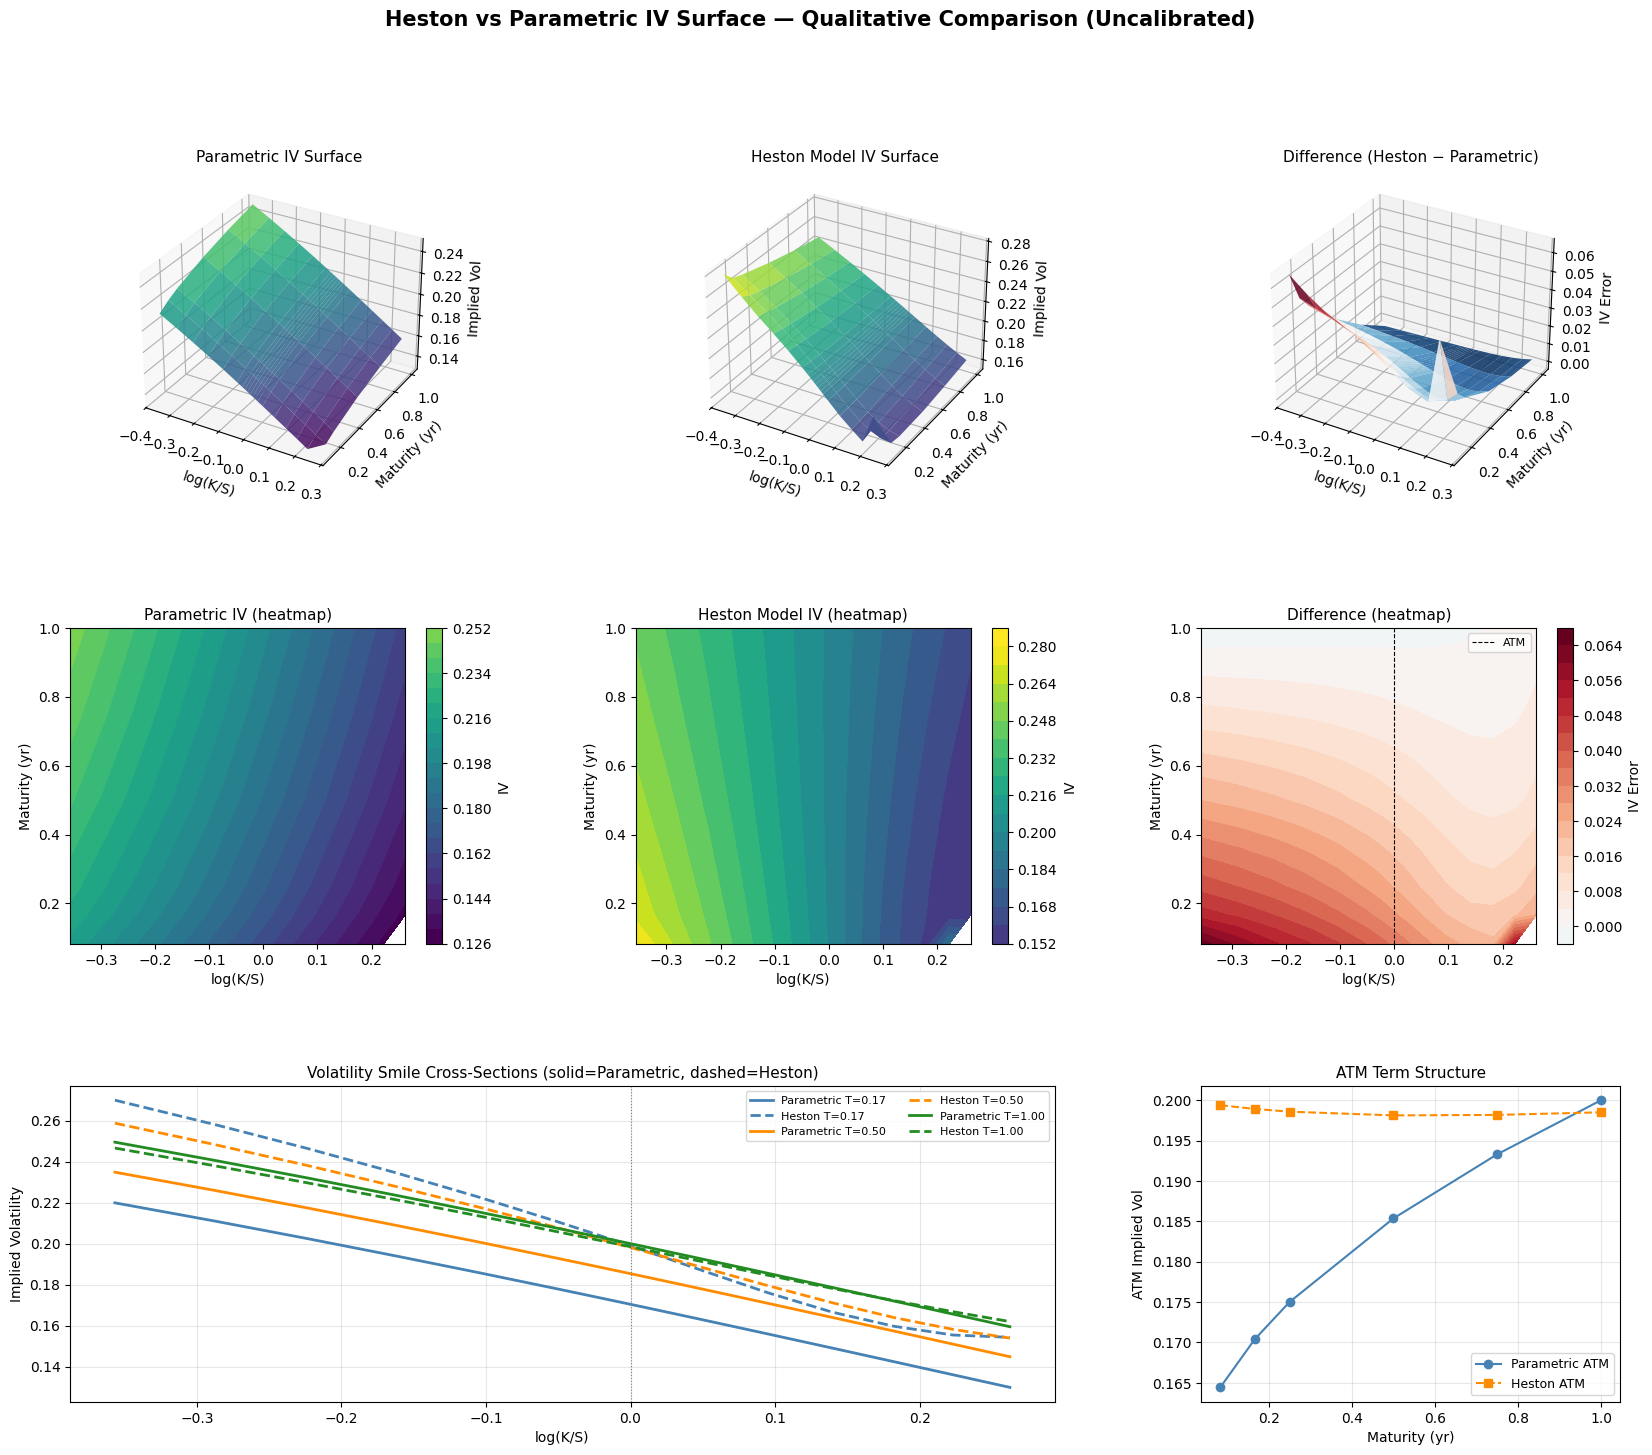


Difference statistics (Heston − Parametric):
  Mean diff  : +0.0185
  RMSE       : 0.0244
  Max abs    : 0.0661

Note: These surfaces use independent parameterizations — differences
are expected. Calibration would be needed to minimize the gap.


In [41]:

# Drop rows where either IV failed
df_clean = df.dropna(subset=['true_iv', 'heston_iv'])

# ── 3. Pivot to 2D grids for surface plots ───────────────────────────────────
def make_surface_grids(df, value_col):
    """
    Returns (strikes, maturities, iv_grid) where iv_grid[i,j] corresponds
    to maturities[i], strikes[j].  Only uses calls for a clean surface.
    """
    calls = df[df['option_type'] == 'call'].copy()
    strikes   = np.sort(calls['strike'].unique())
    maturities = np.sort(calls['maturity'].unique())
    
    grid = np.full((len(maturities), len(strikes)), np.nan)
    for i, T in enumerate(maturities):
        for j, K in enumerate(strikes):
            mask = (calls['maturity'] == T) & (calls['strike'] == K)
            if mask.any():
                grid[i, j] = calls.loc[mask, value_col].values[0]
    
    return strikes, maturities, grid


strikes, maturities, synth_grid  = make_surface_grids(df_clean, 'true_iv')
_,       _,          heston_grid = make_surface_grids(df_clean, 'heston_iv')
residual_grid = heston_grid - synth_grid          # Heston minus market
K_mesh, T_mesh = np.meshgrid(strikes, maturities)

# ── 4. Moneyness axis (more informative than raw strike) ────────────────────
log_moneyness = np.log(K_mesh / S)

# ── 5. Plotting ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Heston vs Parametric IV Surface — Qualitative Comparison (Uncalibrated)',
             fontsize=15, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

vmin = np.nanmin([synth_grid, heston_grid])
vmax = np.nanmax([synth_grid, heston_grid])

# ── Row 1: 3D surfaces ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0], projection='3d')
ax1.plot_surface(log_moneyness, T_mesh, synth_grid,
                 cmap='viridis', alpha=0.85, vmin=vmin, vmax=vmax)
ax1.set_title('Parametric IV Surface', fontsize=11)
ax1.set_xlabel('log(K/S)')
ax1.set_ylabel('Maturity (yr)')
ax1.set_zlabel('Implied Vol')

ax2 = fig.add_subplot(gs[0, 1], projection='3d')
ax2.plot_surface(log_moneyness, T_mesh, heston_grid,
                 cmap='viridis', alpha=0.85, vmin=vmin, vmax=vmax)
ax2.set_title('Heston Model IV Surface', fontsize=11)
ax2.set_xlabel('log(K/S)')
ax2.set_ylabel('Maturity (yr)')
ax2.set_zlabel('Implied Vol')

ax3 = fig.add_subplot(gs[0, 2], projection='3d')
res_abs = np.abs(residual_grid)
ax3.plot_surface(log_moneyness, T_mesh, residual_grid,
                 cmap='RdBu_r', alpha=0.85)
ax3.set_title('Difference (Heston − Parametric)', fontsize=11)
ax3.set_xlabel('log(K/S)')
ax3.set_ylabel('Maturity (yr)')
ax3.set_zlabel('IV Error')

# ── Row 2: Heatmaps ──────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
im4 = ax4.contourf(log_moneyness, T_mesh, synth_grid,
                   levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
plt.colorbar(im4, ax=ax4, label='IV')
ax4.set_title('Parametric IV (heatmap)', fontsize=11)
ax4.set_xlabel('log(K/S)'); ax4.set_ylabel('Maturity (yr)')

ax5 = fig.add_subplot(gs[1, 1])
im5 = ax5.contourf(log_moneyness, T_mesh, heston_grid,
                   levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
plt.colorbar(im5, ax=ax5, label='IV')
ax5.set_title('Heston Model IV (heatmap)', fontsize=11)
ax5.set_xlabel('log(K/S)'); ax5.set_ylabel('Maturity (yr)')

ax6 = fig.add_subplot(gs[1, 2])
res_max = np.nanmax(np.abs(residual_grid))
im6 = ax6.contourf(log_moneyness, T_mesh, residual_grid,
                   levels=20, cmap='RdBu_r',
                   vmin=-res_max, vmax=res_max)
plt.colorbar(im6, ax=ax6, label='IV Error')
ax6.set_title('Difference (heatmap)', fontsize=11)
ax6.set_xlabel('log(K/S)'); ax6.set_ylabel('Maturity (yr)')
ax6.axvline(0, color='black', linewidth=0.8, linestyle='--', label='ATM')
ax6.legend(fontsize=8)

# ── Row 3: Cross-section slices ───────────────────────────────────────────────
# Pick 3 representative maturities for smile cross sections
n_mats = len(maturities)
slice_indices = [n_mats // 6, n_mats // 2, int(5 * n_mats / 6)]
colors = ['steelblue', 'darkorange', 'forestgreen']

ax7 = fig.add_subplot(gs[2, 0:2])   # wider panel for smiles
for idx, color in zip(slice_indices, colors):
    T_val = maturities[idx]
    lm_row = log_moneyness[idx, :]
    ax7.plot(lm_row, synth_grid[idx, :],
             color=color, linewidth=2,
             label=f'Parametric T={T_val:.2f}')
    ax7.plot(lm_row, heston_grid[idx, :],
             color=color, linewidth=2, linestyle='--',
             label=f'Heston T={T_val:.2f}')

ax7.axvline(0, color='grey', linewidth=0.8, linestyle=':')
ax7.set_title('Volatility Smile Cross-Sections (solid=Parametric, dashed=Heston)', fontsize=11)
ax7.set_xlabel('log(K/S)')
ax7.set_ylabel('Implied Volatility')
ax7.legend(fontsize=8, ncol=2)
ax7.grid(alpha=0.3)

# Term structure at ATM
ax8 = fig.add_subplot(gs[2, 2])
atm_idx = np.argmin(np.abs(strikes - S))   # closest strike to spot
ax8.plot(maturities, synth_grid[:,  atm_idx],
         'o-', color='steelblue', label='Parametric ATM')
ax8.plot(maturities, heston_grid[:, atm_idx],
         's--', color='darkorange', label='Heston ATM')
ax8.set_title('ATM Term Structure', fontsize=11)
ax8.set_xlabel('Maturity (yr)')
ax8.set_ylabel('ATM Implied Vol')
ax8.legend(fontsize=9)
ax8.grid(alpha=0.3)

plt.savefig('heston_vs_parametric_iv_surface.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDifference statistics (Heston − Parametric):")
print(f"  Mean diff  : {np.nanmean(residual_grid):+.4f}")
print(f"  RMSE       : {np.nanmean(residual_grid**2)**0.5:.4f}")
print(f"  Max abs    : {np.nanmax(np.abs(residual_grid)):.4f}")
print(f"\nNote: These surfaces use independent parameterizations — differences")
print(f"are expected. Calibration would be needed to minimize the gap.")

# Phase 5

### Loss Function  
$L(\theta)=\sum_{i,j}\omega_{ij}​(σ_{ij}^{market}​−σ_{ij}^{Heston​}(θ))^2$


In [42]:
market_calls = opt_prices_df_skew_smile_structure[opt_prices_df_skew_smile_structure['option_type'] == 'call']

strikes      = market_calls['strike'].to_numpy()
maturities   = market_calls['maturity'].to_numpy()
market_ivs   = market_calls['true_iv'].to_numpy()   # or whichever IV column is your target

In [43]:
heston_params
S = 100
r = 0.05
q = 0

v0 = 0.04      # 20% initial vol
kappa = 2.0    # moderate mean reversion
theta = 0.04   # 20% long-run vol
xi = 0.3       # moderate vol-of-vol
rho = -0.7      # typical equity negative correlation


def heston_iv_surface(strikes, maturities, S, r, v0, kappa, theta, xi, rho, opt_type='call'):
    pricers = {'call': heston_call_price, 'put': heston_put_price}
    pricer = pricers[opt_type]
    IVs = []
    for strike, maturity in zip(strikes, maturities):
        price = pricer(S=S, K=strike, T=maturity, r=r, v0=v0, kappa=kappa, theta=theta, xi=xi, rho=rho)
        iv = safe_implied_volatility(price, S=S, K=strike, T=maturity, r=r, option_type=opt_type)
        IVs.append(iv)
    return np.array(IVs)

heston_ivs = heston_iv_surface(strikes, maturities, S, r, v0, kappa, theta, xi, rho, opt_type='call')

heston_ivs

array([0.28006348, 0.26361429, 0.24912659, 0.2366915 , 0.22436528,
       0.21191998, 0.20691251, 0.20440115, 0.20188769, 0.19937645,
       0.19687152, 0.19437612, 0.19189306, 0.18698084, 0.1754393 ,
       0.16590255, 0.15724741, 0.18560316,        nan, 0.26997736,
       0.25811533, 0.24635959, 0.23460271, 0.222785  , 0.21087661,
       0.20609194, 0.20369822, 0.20130554, 0.19891556, 0.19653034,
       0.19415263, 0.19178599, 0.18710423, 0.17598997, 0.16655562,
       0.15969616, 0.15543541, 0.15431877, 0.26687228, 0.25541045,
       0.24404352, 0.2327087 , 0.22135703, 0.20996717, 0.20540605,
       0.20312698, 0.20085049, 0.19857822, 0.19631208, 0.19405439,
       0.19180789, 0.18736216, 0.17674679, 0.16747963, 0.16033456,
       0.15556494, 0.15281052, 0.2587617 , 0.24832755, 0.23805938,
       0.227915  , 0.21786917, 0.20792223, 0.20397865, 0.20201662,
       0.20006219, 0.19811633, 0.19618018, 0.19425501, 0.1923423 ,
       0.1885609 , 0.17946187, 0.17113171, 0.16393841, 0.15817

In [44]:
def iv_loss(market_ivs, heston_ivs):
    mask = np.isfinite(market_ivs) & np.isfinite(heston_ivs)
    
    if mask.sum() == 0:
        return np.inf
    
    return ((market_ivs[mask] - heston_ivs[mask]) ** 2).sum() / mask.sum()
    

In [45]:
#heston_params = ['v0', 'kappa', 'theta', 'xi':, 'rho']

[0.04, 2.0, 0.04, 0.3, -0.7]

def objective(heston_params, strikes, maturities, market_ivs, S, r, opt_type):
    v0, kappa, theta, xi, rho = heston_params

    heston_ivs = heston_iv_surface(strikes, maturities, S, r, v0, kappa, theta, xi, rho, opt_type=opt_type)

    loss = iv_loss(market_ivs, heston_ivs)
    return loss

In [46]:
bounds = [(1e-4, 1.0), (1e-4, 15.0), (1e-4, 1.0), (1e-4, 2.0), (-0.99, 0.99)]

In [47]:
from scipy.optimize import minimize

x0 = np.array([0.04, 2.0, 0.04, 0.3, -0.7])

bounds = [(1e-4, 1.0), (1e-4, 15.0), (1e-4, 1.0), (1e-4, 2.0), (-0.99, 0.99)]

result = minimize(
    fun=objective,
    x0=x0,
    args=(strikes, maturities, market_ivs, S, r, 'call'),
    method='L-BFGS-B',
    bounds=bounds
)

In [48]:
print(result.success)
print(result.message)
print(f"Function evaluations: {result.nfev}")
print(f"Iterations: {result.nit}")

params = ['v0', 'kappa', 'theta', 'xi', 'rho']
for name, val in zip(params, result.x):
    print(f"{name}: {val:.4f}")

print(f"Final MSE: {result.fun:.6f}")
print(f"Final RMSE: {np.sqrt(result.fun):.4f}")

True
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Function evaluations: 450
Iterations: 8
v0: 0.0340
kappa: 2.0000
theta: 0.0397
xi: 0.2989
rho: -0.6999
Final MSE: 0.000370
Final RMSE: 0.0192


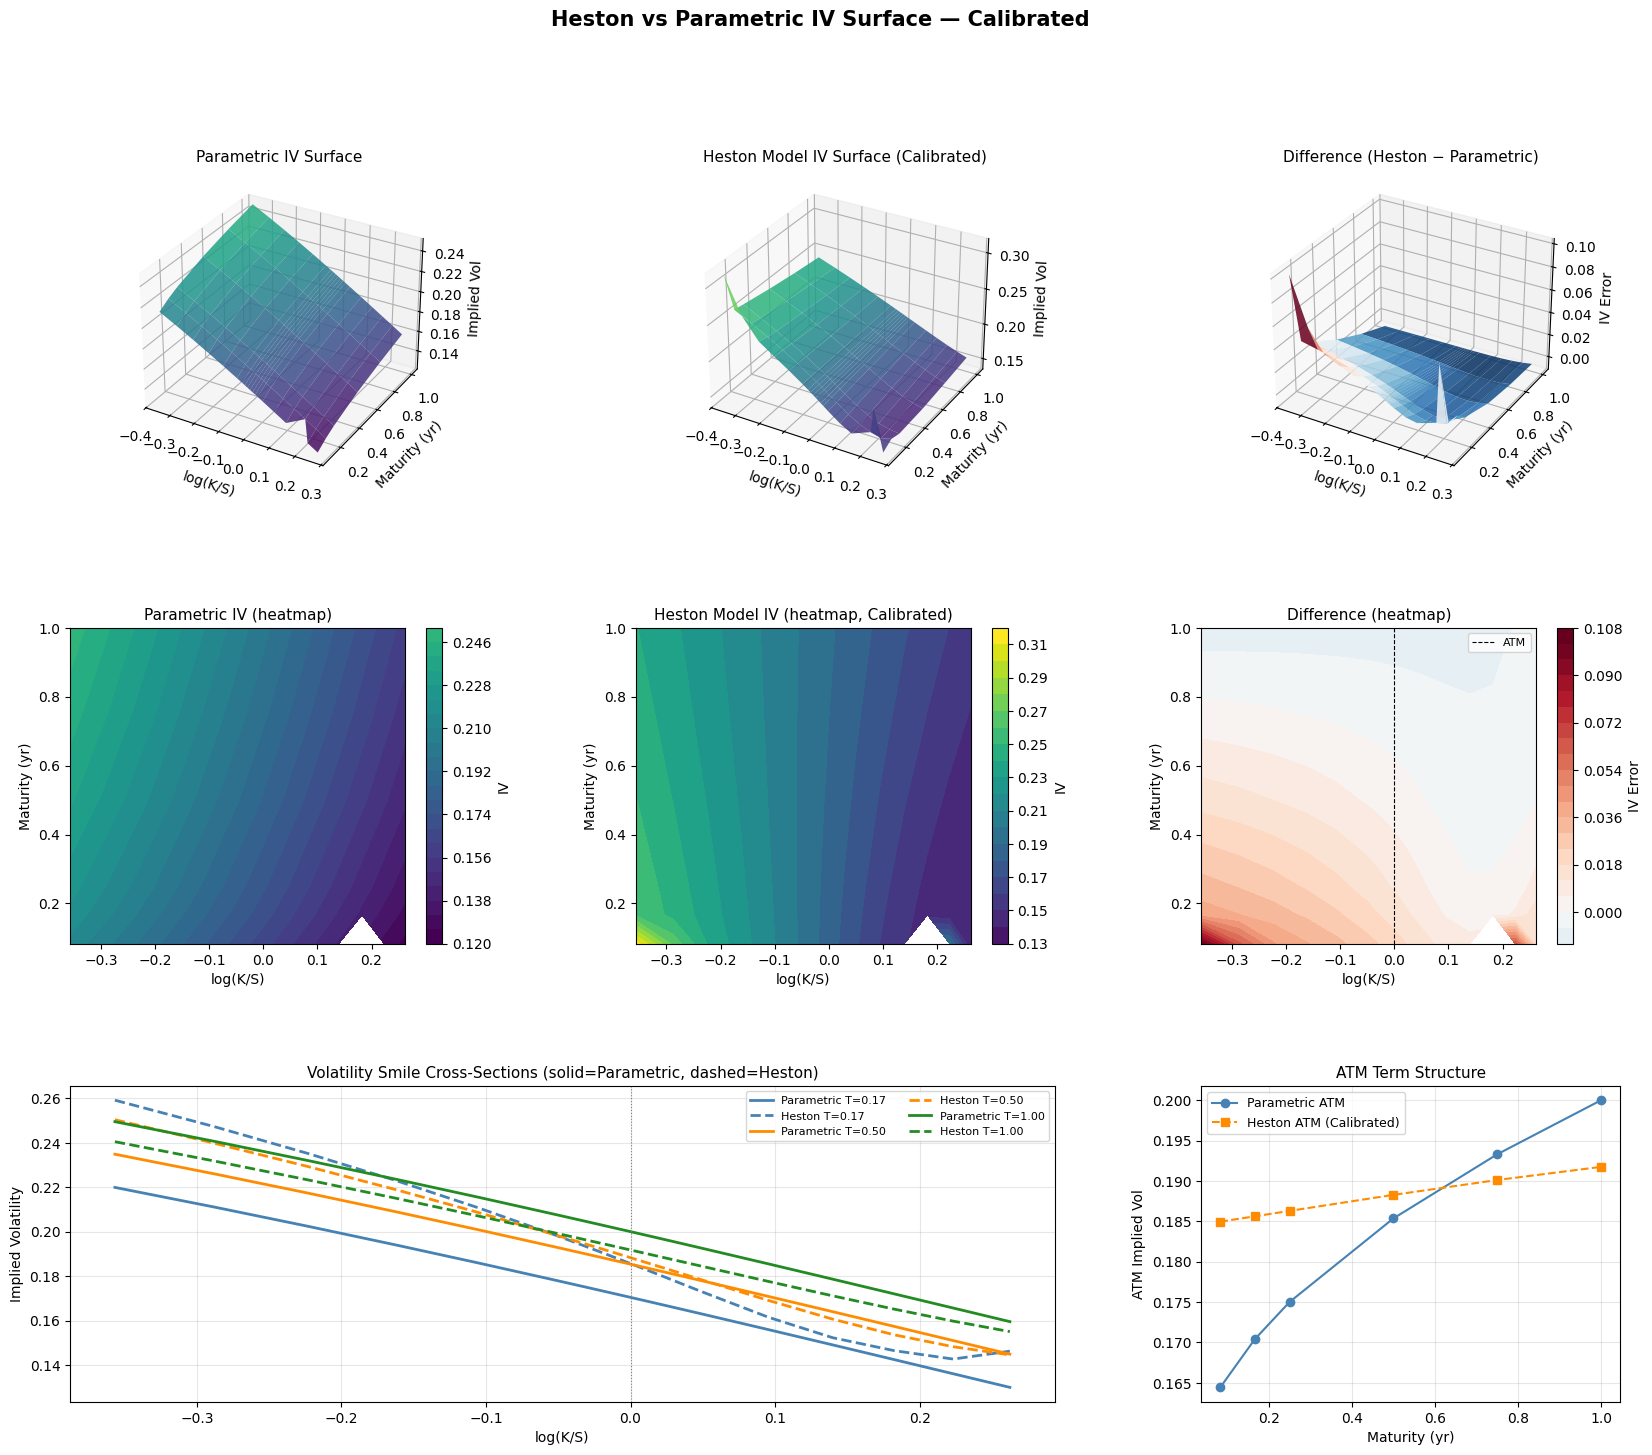

Calibrated Heston parameters:
  v0: 0.0340
  kappa: 2.0000
  theta: 0.0397
  xi: 0.2989
  rho: -0.6999

Difference statistics (Calibrated Heston − Parametric):
  Mean diff  : +0.0089
  RMSE       : 0.0192
  Max abs    : 0.1022


In [49]:

# ── Calibrated Heston vs Parametric IV Surface ───────────────────────────────
v0_cal, kappa_cal, theta_cal, xi_cal, rho_cal = result.x

calibrated_params = {
    'v0': v0_cal, 'kappa': kappa_cal, 'theta': theta_cal,
    'xi': xi_cal, 'rho': rho_cal
}

# Compute Heston IV surface with calibrated params (same as Phase 4)
df_cal = compute_heston_iv_surface_df(opt_prices_df_skew_smile_structure, S, r, calibrated_params)
df_cal_clean = df_cal.dropna(subset=['true_iv', 'heston_iv'])

# Build 2D grids via make_surface_grids
strikes_grid, maturities_grid, synth_grid_cal   = make_surface_grids(df_cal_clean, 'true_iv')
_,             _,               cal_heston_grid  = make_surface_grids(df_cal_clean, 'heston_iv')

residual_cal = cal_heston_grid - synth_grid_cal
K_mesh_cal, T_mesh_cal = np.meshgrid(strikes_grid, maturities_grid)
log_moneyness_cal = np.log(K_mesh_cal / S)

# ── Plotting ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Heston vs Parametric IV Surface — Calibrated',
             fontsize=15, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

vmin = np.nanmin([synth_grid_cal, cal_heston_grid])
vmax = np.nanmax([synth_grid_cal, cal_heston_grid])

# ── Row 1: 3D surfaces ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0], projection='3d')
ax1.plot_surface(log_moneyness_cal, T_mesh_cal, synth_grid_cal,
                 cmap='viridis', alpha=0.85, vmin=vmin, vmax=vmax)
ax1.set_title('Parametric IV Surface', fontsize=11)
ax1.set_xlabel('log(K/S)'); ax1.set_ylabel('Maturity (yr)'); ax1.set_zlabel('Implied Vol')

ax2 = fig.add_subplot(gs[0, 1], projection='3d')
ax2.plot_surface(log_moneyness_cal, T_mesh_cal, cal_heston_grid,
                 cmap='viridis', alpha=0.85, vmin=vmin, vmax=vmax)
ax2.set_title('Heston Model IV Surface (Calibrated)', fontsize=11)
ax2.set_xlabel('log(K/S)'); ax2.set_ylabel('Maturity (yr)'); ax2.set_zlabel('Implied Vol')

ax3 = fig.add_subplot(gs[0, 2], projection='3d')
ax3.plot_surface(log_moneyness_cal, T_mesh_cal, residual_cal,
                 cmap='RdBu_r', alpha=0.85)
ax3.set_title('Difference (Heston − Parametric)', fontsize=11)
ax3.set_xlabel('log(K/S)'); ax3.set_ylabel('Maturity (yr)'); ax3.set_zlabel('IV Error')

# ── Row 2: Heatmaps ──────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
im4 = ax4.contourf(log_moneyness_cal, T_mesh_cal, synth_grid_cal,
                   levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
plt.colorbar(im4, ax=ax4, label='IV')
ax4.set_title('Parametric IV (heatmap)', fontsize=11)
ax4.set_xlabel('log(K/S)'); ax4.set_ylabel('Maturity (yr)')

ax5 = fig.add_subplot(gs[1, 1])
im5 = ax5.contourf(log_moneyness_cal, T_mesh_cal, cal_heston_grid,
                   levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
plt.colorbar(im5, ax=ax5, label='IV')
ax5.set_title('Heston Model IV (heatmap, Calibrated)', fontsize=11)
ax5.set_xlabel('log(K/S)'); ax5.set_ylabel('Maturity (yr)')

ax6 = fig.add_subplot(gs[1, 2])
res_max = np.nanmax(np.abs(residual_cal))
im6 = ax6.contourf(log_moneyness_cal, T_mesh_cal, residual_cal,
                   levels=20, cmap='RdBu_r',
                   vmin=-res_max, vmax=res_max)
plt.colorbar(im6, ax=ax6, label='IV Error')
ax6.set_title('Difference (heatmap)', fontsize=11)
ax6.set_xlabel('log(K/S)'); ax6.set_ylabel('Maturity (yr)')
ax6.axvline(0, color='black', linewidth=0.8, linestyle='--', label='ATM')
ax6.legend(fontsize=8)

# ── Row 3: Cross-section slices ──────────────────────────────────────────────
n_mats = len(maturities_grid)
slice_indices = [n_mats // 6, n_mats // 2, int(5 * n_mats / 6)]
colors = ['steelblue', 'darkorange', 'forestgreen']

ax7 = fig.add_subplot(gs[2, 0:2])
for idx, color in zip(slice_indices, colors):
    T_val = maturities_grid[idx]
    lm_row = log_moneyness_cal[idx, :]
    ax7.plot(lm_row, synth_grid_cal[idx, :],
             color=color, linewidth=2, label=f'Parametric T={T_val:.2f}')
    ax7.plot(lm_row, cal_heston_grid[idx, :],
             color=color, linewidth=2, linestyle='--', label=f'Heston T={T_val:.2f}')

ax7.axvline(0, color='grey', linewidth=0.8, linestyle=':')
ax7.set_title('Volatility Smile Cross-Sections (solid=Parametric, dashed=Heston)', fontsize=11)
ax7.set_xlabel('log(K/S)'); ax7.set_ylabel('Implied Volatility')
ax7.legend(fontsize=8, ncol=2); ax7.grid(alpha=0.3)

ax8 = fig.add_subplot(gs[2, 2])
atm_idx = np.argmin(np.abs(strikes_grid - S))
ax8.plot(maturities_grid, synth_grid_cal[:, atm_idx],
         'o-', color='steelblue', label='Parametric ATM')
ax8.plot(maturities_grid, cal_heston_grid[:, atm_idx],
         's--', color='darkorange', label='Heston ATM (Calibrated)')
ax8.set_title('ATM Term Structure', fontsize=11)
ax8.set_xlabel('Maturity (yr)'); ax8.set_ylabel('ATM Implied Vol')
ax8.legend(fontsize=9); ax8.grid(alpha=0.3)

plt.savefig('heston_vs_parametric_iv_surface_calibrated.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Calibrated Heston parameters:")
for name, val in zip(['v0', 'kappa', 'theta', 'xi', 'rho'], result.x):
    print(f"  {name}: {val:.4f}")
print(f"\nDifference statistics (Calibrated Heston − Parametric):")
print(f"  Mean diff  : {np.nanmean(residual_cal):+.4f}")
print(f"  RMSE       : {np.nanmean(residual_cal**2)**0.5:.4f}")
print(f"  Max abs    : {np.nanmax(np.abs(residual_cal)):.4f}")


### Parameter sensitivity tests
1d slices with 4 parameters fixed and 1 varying.  
Calculate loss at each point.

In [50]:
param_sweep_config = {
    'v0':    {'range': (0.01, 0.25),  'label': 'Initial Variance',       'n_points': 50},
    'kappa': {'range': (0.5,  4.0),   'label': 'Mean Reversion Speed',   'n_points': 50},
    'theta': {'range': (0.01, 0.25),  'label': 'Long-run Variance',      'n_points': 50},
    'xi':    {'range': (0.1,  0.6),   'label': 'Vol of Vol',             'n_points': 50},
    'rho':   {'range': (-0.99, 0.1),  'label': 'Spot-Vol Correlation',   'n_points': 50},
}

In [51]:
sweep_results = {}
param_names = ['v0', 'kappa', 'theta', 'xi', 'rho']
calibrated = result.x.copy()

for idx, (param_name, config) in enumerate(param_sweep_config.items()):
    low, high = config['range']
    sweep_vals = np.linspace(low, high, config['n_points'])
    losses = []
    for val in sweep_vals:
        test_params = calibrated.copy()
        test_params[idx] = val
        losses.append(objective(test_params, strikes, maturities, market_ivs, S, r, 'call'))
    sweep_results[param_name] = {
        'values': sweep_vals,
        'losses': np.array(losses),
        'label': config['label'],
        'calibrated_value': calibrated[idx],
        'calibrated_loss': result.fun,
    }
    print(f"  {param_name}: done")

print("Parameter sweep complete.")

  v0: done
  kappa: done
  theta: done
  xi: done
  rho: done
Parameter sweep complete.


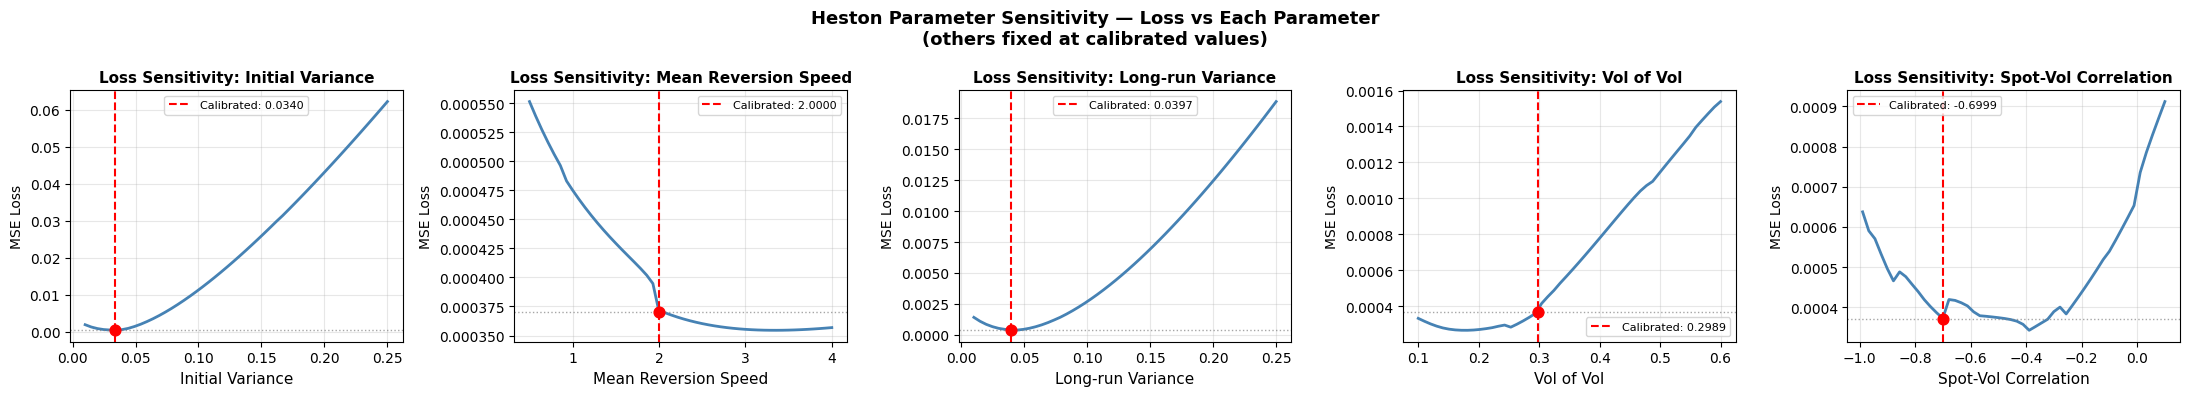

Saved: heston_loss_sensitivity.png


In [52]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (param_name, res) in zip(axes, sweep_results.items()):
    ax.plot(res['values'], res['losses'], lw=2, color='steelblue')
    ax.axvline(res['calibrated_value'], color='red', linestyle='--', lw=1.5,
               label=f"Calibrated: {res['calibrated_value']:.4f}")
    ax.axhline(res['calibrated_loss'], color='gray', linestyle=':', lw=1, alpha=0.7)
    ax.scatter([res['calibrated_value']], [res['calibrated_loss']], color='red', zorder=5, s=60)
    ax.set_xlabel(res['label'], fontsize=11)
    ax.set_ylabel('MSE Loss', fontsize=10)
    ax.set_title(f'Loss Sensitivity: {res["label"]}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Heston Parameter Sensitivity — Loss vs Each Parameter\n(others fixed at calibrated values)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heston_loss_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: heston_loss_sensitivity.png")

In [53]:
from itertools import combinations

N_2D = 20  # points per axis — 10 pairs × 20×20 = 4,000 objective calls total
sweep2d_results = {}

for (i, j) in combinations(range(len(param_names)), 2):
    name_i, name_j = param_names[i], param_names[j]
    cfg_i, cfg_j = param_sweep_config[name_i], param_sweep_config[name_j]

    vals_i = np.linspace(*cfg_i['range'], N_2D)
    vals_j = np.linspace(*cfg_j['range'], N_2D)

    loss_grid = np.zeros((N_2D, N_2D))
    for ii, vi in enumerate(vals_i):
        for jj, vj in enumerate(vals_j):
            test_params = calibrated.copy()
            test_params[i] = vi
            test_params[j] = vj
            loss_grid[ii, jj] = objective(test_params, strikes, maturities, market_ivs, S, r, 'call')

    sweep2d_results[(i, j)] = {
        'vals_i': vals_i,   # x-axis values (param i)
        'vals_j': vals_j,   # y-axis values (param j)
        'loss_grid': loss_grid,  # shape (N_2D, N_2D): [ii, jj]
        'name_i': name_i, 'name_j': name_j,
        'label_i': cfg_i['label'], 'label_j': cfg_j['label'],
    }
    print(f"  ({name_i}, {name_j}): done")

print("2D sweep complete.")

  (v0, kappa): done
  (v0, theta): done
  (v0, xi): done
  (v0, rho): done
  (kappa, theta): done
  (kappa, xi): done
  (kappa, rho): done
  (theta, xi): done
  (theta, rho): done
  (xi, rho): done
2D sweep complete.


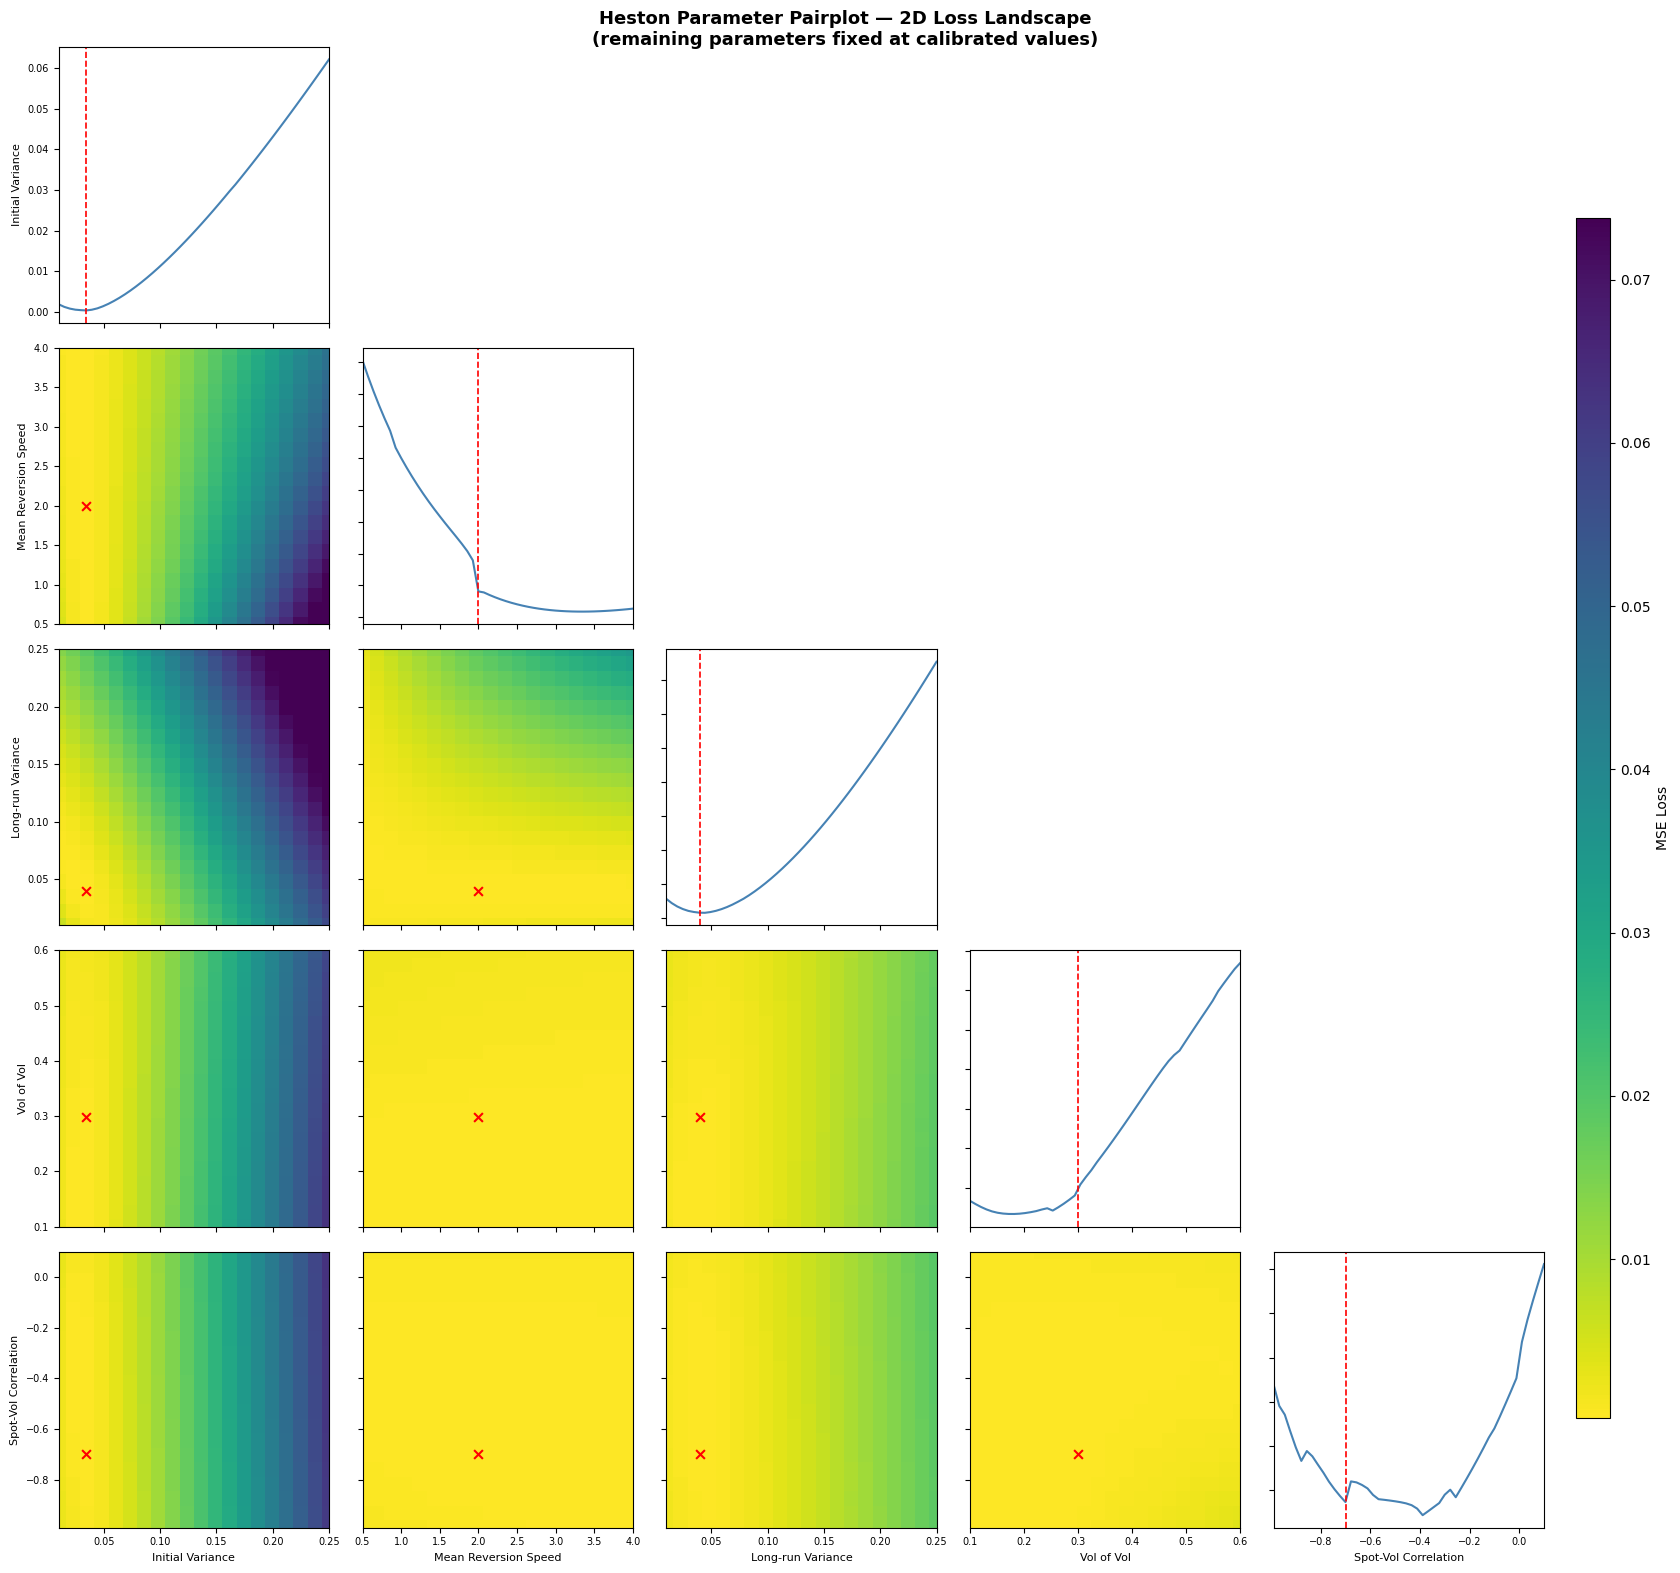

Saved: heston_loss_pairplot.png


In [54]:
n_params = len(param_names)

# Shared colour scale across all 2D heatmaps (clip outliers with percentile)
all_losses = np.concatenate([v['loss_grid'].ravel() for v in sweep2d_results.values()])
vmin, vmax = np.nanpercentile(all_losses, 1), np.nanpercentile(all_losses, 99)

fig, axes = plt.subplots(n_params, n_params, figsize=(17, 16))

im = None
for row in range(n_params):
    for col in range(n_params):
        ax = axes[row, col]

        if row == col:
            # Diagonal: 1D loss curve from sweep_results
            res = sweep_results[param_names[row]]
            ax.plot(res['values'], res['losses'], lw=1.5, color='steelblue')
            ax.axvline(res['calibrated_value'], color='red', linestyle='--', lw=1.2)
            ax.set_xlim(res['values'][0], res['values'][-1])

        elif row > col:
            # Lower triangle: 2D loss heatmap (shared vmin/vmax)
            res2d = sweep2d_results[(col, row)]
            im = ax.pcolormesh(
                res2d['vals_i'], res2d['vals_j'], res2d['loss_grid'].T,
                cmap='viridis_r', shading='auto', vmin=vmin, vmax=vmax
            )
            ax.scatter([calibrated[col]], [calibrated[row]],
                       color='red', s=40, zorder=5, marker='x', linewidths=1.5)
            ax.set_xlim(res2d['vals_i'][0], res2d['vals_i'][-1])
            ax.set_ylim(res2d['vals_j'][0], res2d['vals_j'][-1])

        else:
            # Upper triangle: hide
            ax.set_visible(False)
            continue

        # Axis labels on outer edges only
        ax.tick_params(labelsize=7)
        if col == 0:
            ax.set_ylabel(param_sweep_config[param_names[row]]['label'], fontsize=8)
        else:
            ax.set_yticklabels([])
        if row == n_params - 1:
            ax.set_xlabel(param_sweep_config[param_names[col]]['label'], fontsize=8)
        else:
            ax.set_xticklabels([])

plt.suptitle(
    'Heston Parameter Pairplot — 2D Loss Landscape\n'
    '(remaining parameters fixed at calibrated values)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 0.92, 1])
cbar_ax = fig.add_axes([0.93, 0.1, 0.02, 0.75])
fig.colorbar(im, cax=cbar_ax, label='MSE Loss')
plt.savefig('heston_loss_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: heston_loss_pairplot.png")